# Ookla EDA — Vietnam Fixed Broadband & Mobile/Cellular (Combined)

Same structure/methodology as the Thailand combined notebook. Shared setup (geo, province/region reference, GDP/tier context) runs once; Part 1 and Part 2 each run an independent full EDA pass over their own dataset (fixed vs mobile Ookla tiles).

**Data sources:** ADM1 boundaries from geoBoundaries (simplified); population/area/density/GDP per capita from public sources (Wikipedia/PSA/GSO/Singstat) compiled into `data/reference/vietnam_reference.csv`. GDP unit: USD PPP, 2011.

Run All top-to-bottom to generate outputs.


### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="../../data/ookla/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
    THAILAND_GEOJSON = '../../data/geo/vietnam_provinces.geojson'

    PROVINCE_COL = 'name' 

    perf_tiles_url = "../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

    thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

    # Capture the total bounds of Vietnam's boundaries for the bounding box filter
    state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

FileNotFoundError: [Errno 2] No such file or directory: '../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet'

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

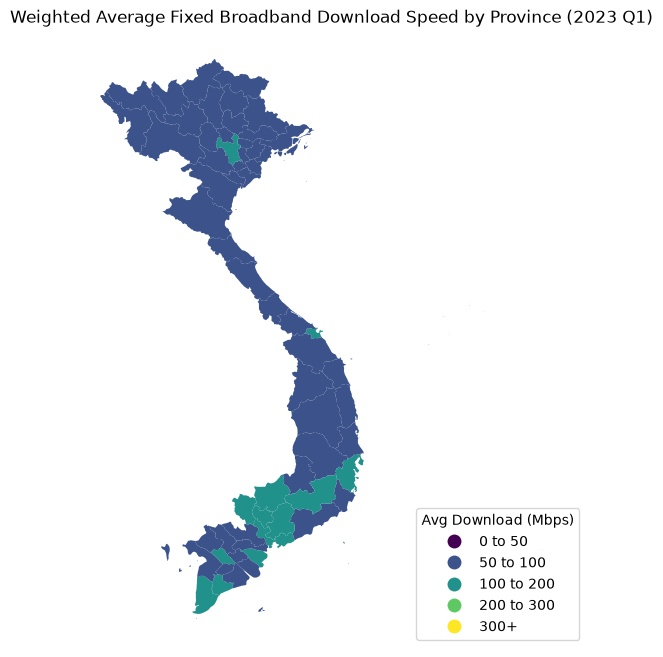

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()

plt.savefig(f'../../outputs/ookla/vietnam/08_province_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import os

file_path = "../../data/ookla/raw"
files = sorted([f for f in os.listdir(file_path) if f.endswith('.parquet')])
print(f"{len(files)} files, reading first for inspection...")

# Read single file to inspect schema — avoid loading 3.7GB at once
df = pd.read_parquet(os.path.join(file_path, files[0]), engine='pyarrow')

23 files, reading first for inspection...


In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


## Province Reference Data

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/vietnam_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 64
Regions: ['Central Highlands', 'Mekong Delta', 'North Central Coast', 'Northeast', 'Northwest', 'Red River Delta', 'South Central Coast', 'Southeast']

    province_en              region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
       An Giang        Mekong Delta   2057000              540                338704.14              1
Bà Rịa–Vũng Tàu           Southeast   1303000              580               3286254.54              1
     Bình Dương           Southeast   2564000              901                327276.61              2
     Bình Phước           Southeast   1313000              145                322186.39              2
     Bình Thuận South Central Coast   1498000              155                276055.50              2
      Bình Định South Central Coast   1679000              245                275959.91              2
       Bạc Liêu        Mekong Delta   1105000              340                330710.59              2
   

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                     provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                            
Southeast                    7        20.04       1055.0            1219194.0            1219194.0
Mekong Delta                13        18.85        480.0             316292.0             316292.0
South Central Coast          8        10.67        282.0             299540.0             299540.0
Red River Delta             10        22.20       1271.0             266559.0             266559.0
Central Highlands            5         6.25        105.0             249900.0             249900.0
Northeast                    9         9.85        215.0             226035.0             226035.0
North Central Coast          6        11.43        204.0             221536.0             221536.0
Northwest                    6         5.42        104.0             169748.0             169748.0


### GDP per Capita vs Population Density — by Region

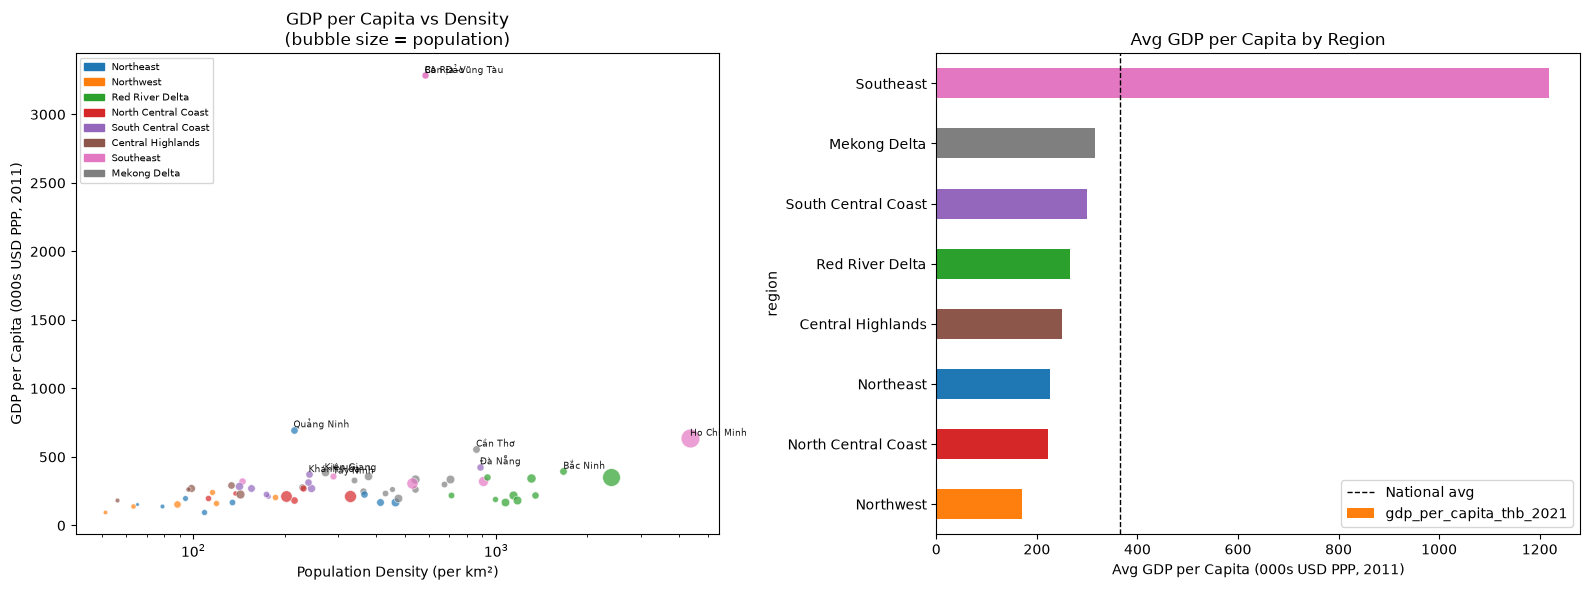

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD PPP, 2011)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD PPP, 2011)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

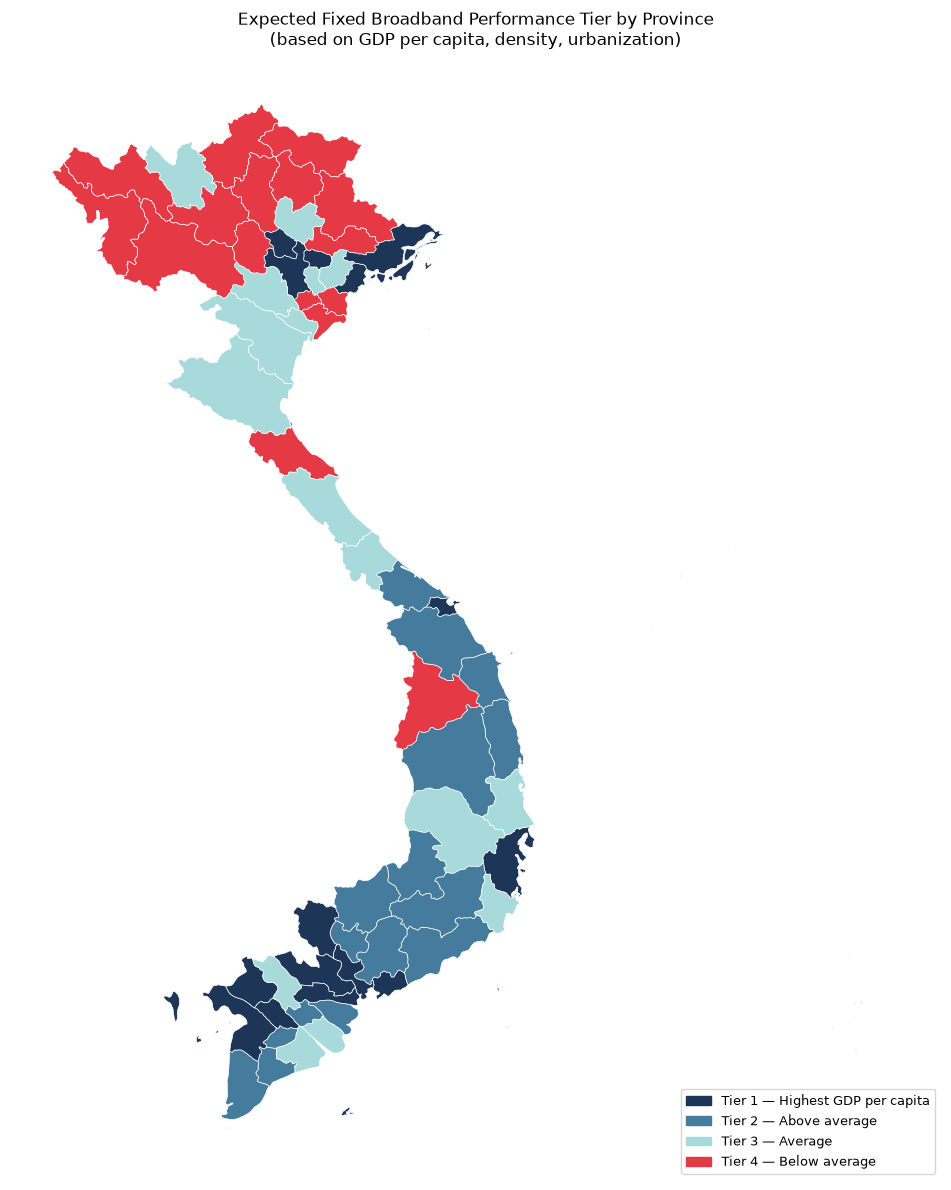

In [18]:
THAILAND_GEOJSON = '../../data/geo/vietnam_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
    province_en              region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bà Rịa–Vũng Tàu           Southeast   1303000               3286254.54              1
        Côn Đảo           Southeast   1303000               3286254.54              1
     Quảng Ninh           Northeast   1387000                699887.25              1
    Ho Chi Minh           Southeast   9125000                638474.09              1
        Cần Thơ        Mekong Delta   1456000                559273.75              1
        Đà Nẵng South Central Coast   1294000                429834.96              1
       Bắc Ninh     Red River Delta   1447000                397659.74              1
     Kiên Giang        Mekong Delta   1789000                387388.18              1
      Khánh Hòa South Central Coast   1371000                373474.50              1
       Tây Ninh           Southeast   1207000                362573.14              1

=== BOTTOM 10 by GDP

---
# Part 1 — Fixed Broadband


## Full EDA — Ookla Fixed Broadband, Vietnam (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/vietnam_provinces.geojson'
PROV_REF    = '../../data/reference/vietnam_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*fixed_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):  188,408 raw tiles → 64 provinces


  2023-Q2 (2023-04-01):  180,669 raw tiles → 64 provinces


  2023-Q3 (2023-07-01):  182,602 raw tiles → 64 provinces


  2023-Q4 (2023-10-01):  183,866 raw tiles → 64 provinces


  2024-Q1 (2024-01-01):  196,246 raw tiles → 64 provinces


...

  2024-Q3 (2024-07-01):  190,998 raw tiles → 64 provinces


  2024-Q4 (2024-10-01):  196,171 raw tiles → 64 provinces


  2025-Q1 (2025-01-01):  194,078 raw tiles → 64 provinces


  2025-Q2 (2025-04-01):  209,082 raw tiles → 64 provinces


  2025-Q4 (2025-10-01):  210,648 raw tiles → 64 provinces

Master shape: (704, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  64

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


In [21]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    64
2023-Q2    64
2023-Q3    64
2023-Q4    64
2024-Q1    64
2024-Q2    64
2024-Q3    64
2024-Q4    64
2025-Q1    64
2025-Q2    64
2025-Q4    64

Overall reliable: 704 / 704 (100.0%)


### 2. Data Quality — Coverage per Province

In [22]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected_n} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 704 | Actual: 704 | Missing: 0

All 64 provinces covered in every quarter.



No quarters with < 100 tests.


In [23]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 704 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

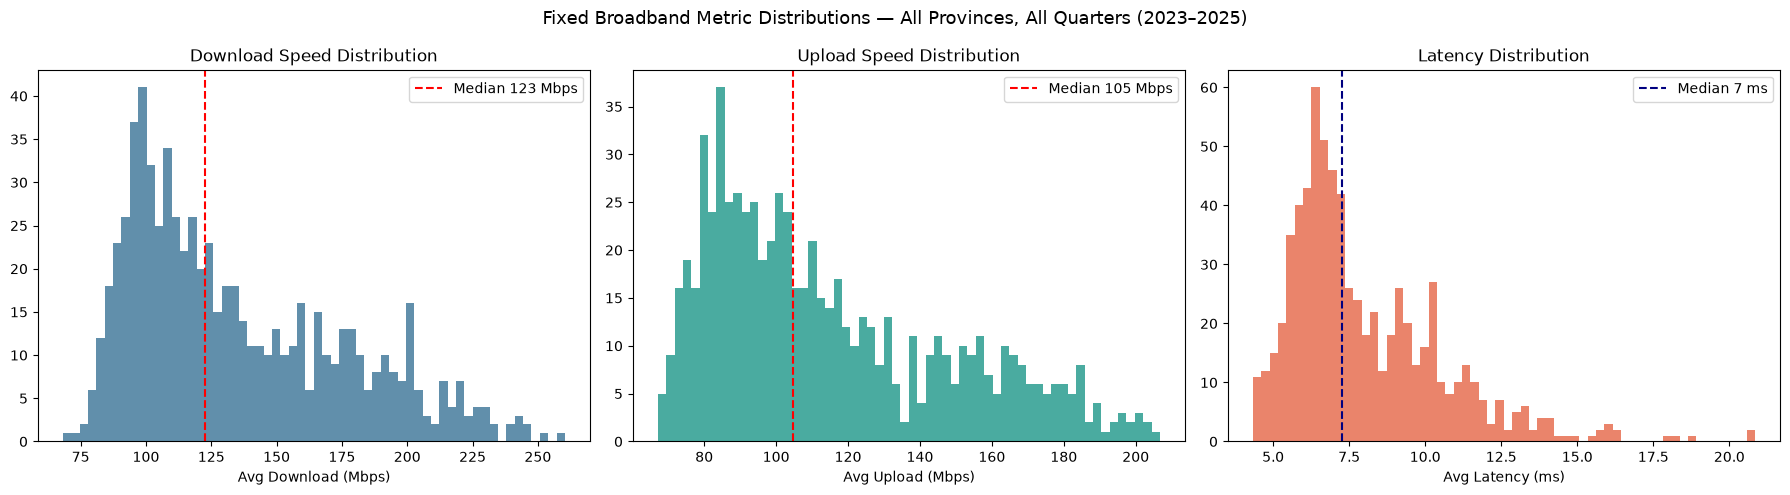

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      704.00      704.00         704.00       704.00
mean       134.62      114.60           8.00     33209.13
std         40.80       33.44           2.53     74029.61
min         68.18       67.10           4.33       196.00
25%        101.22       87.56           6.26      9784.00
50%        122.63      104.57           7.25     16947.00
75%        163.89      137.83           9.35     27551.25
max        260.34      206.72          20.84    581166.00


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

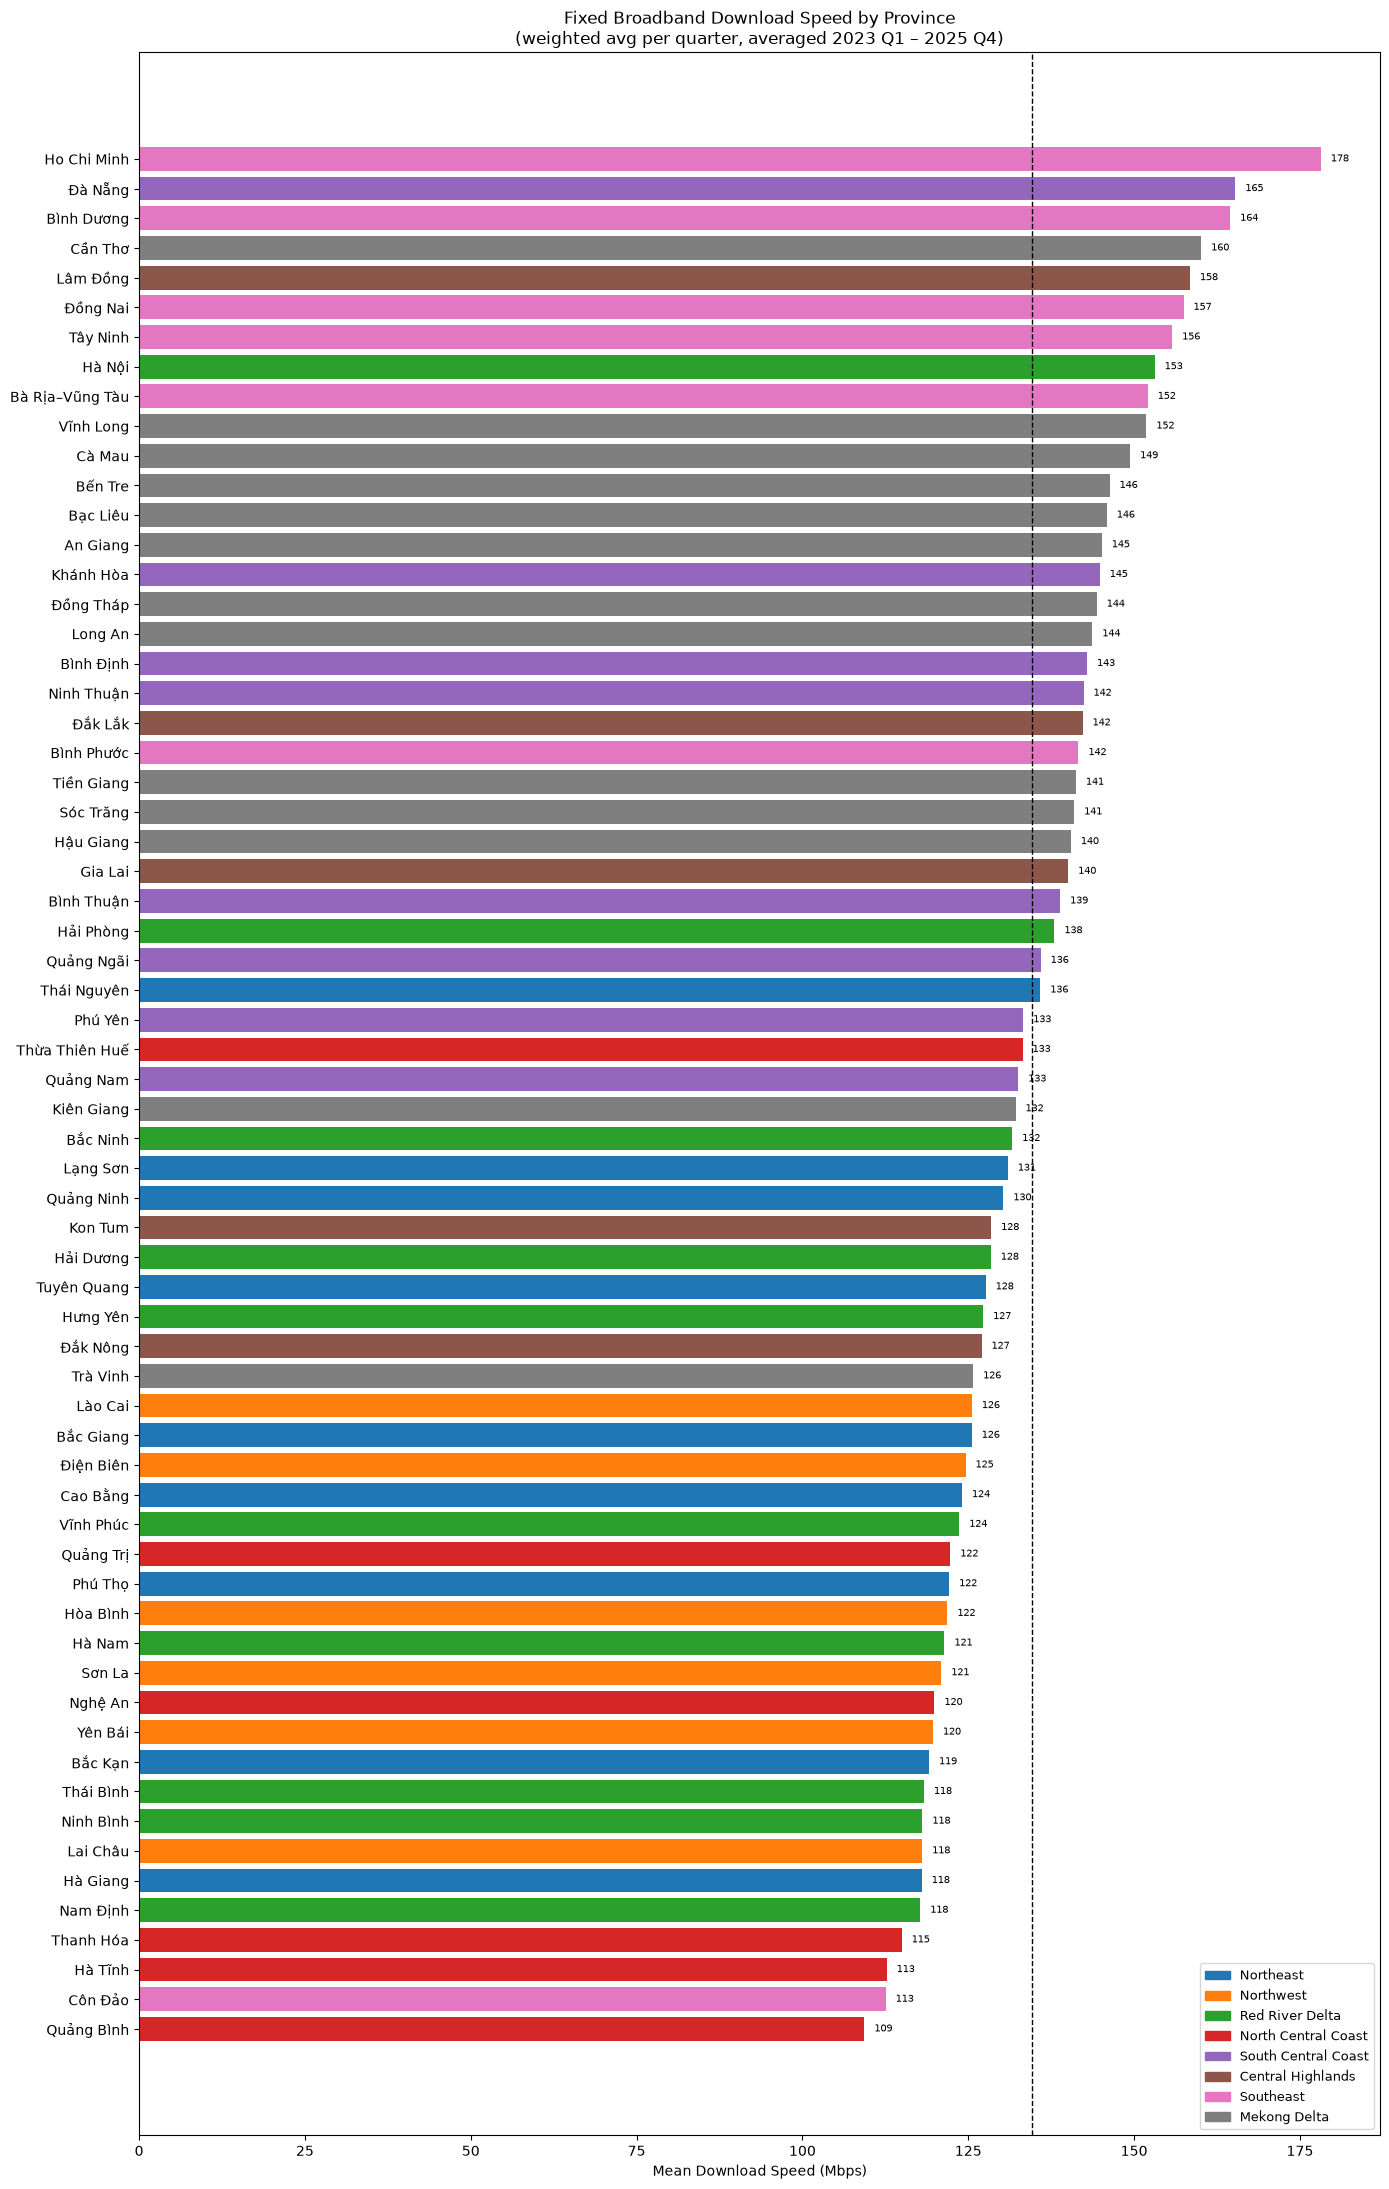

In [25]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

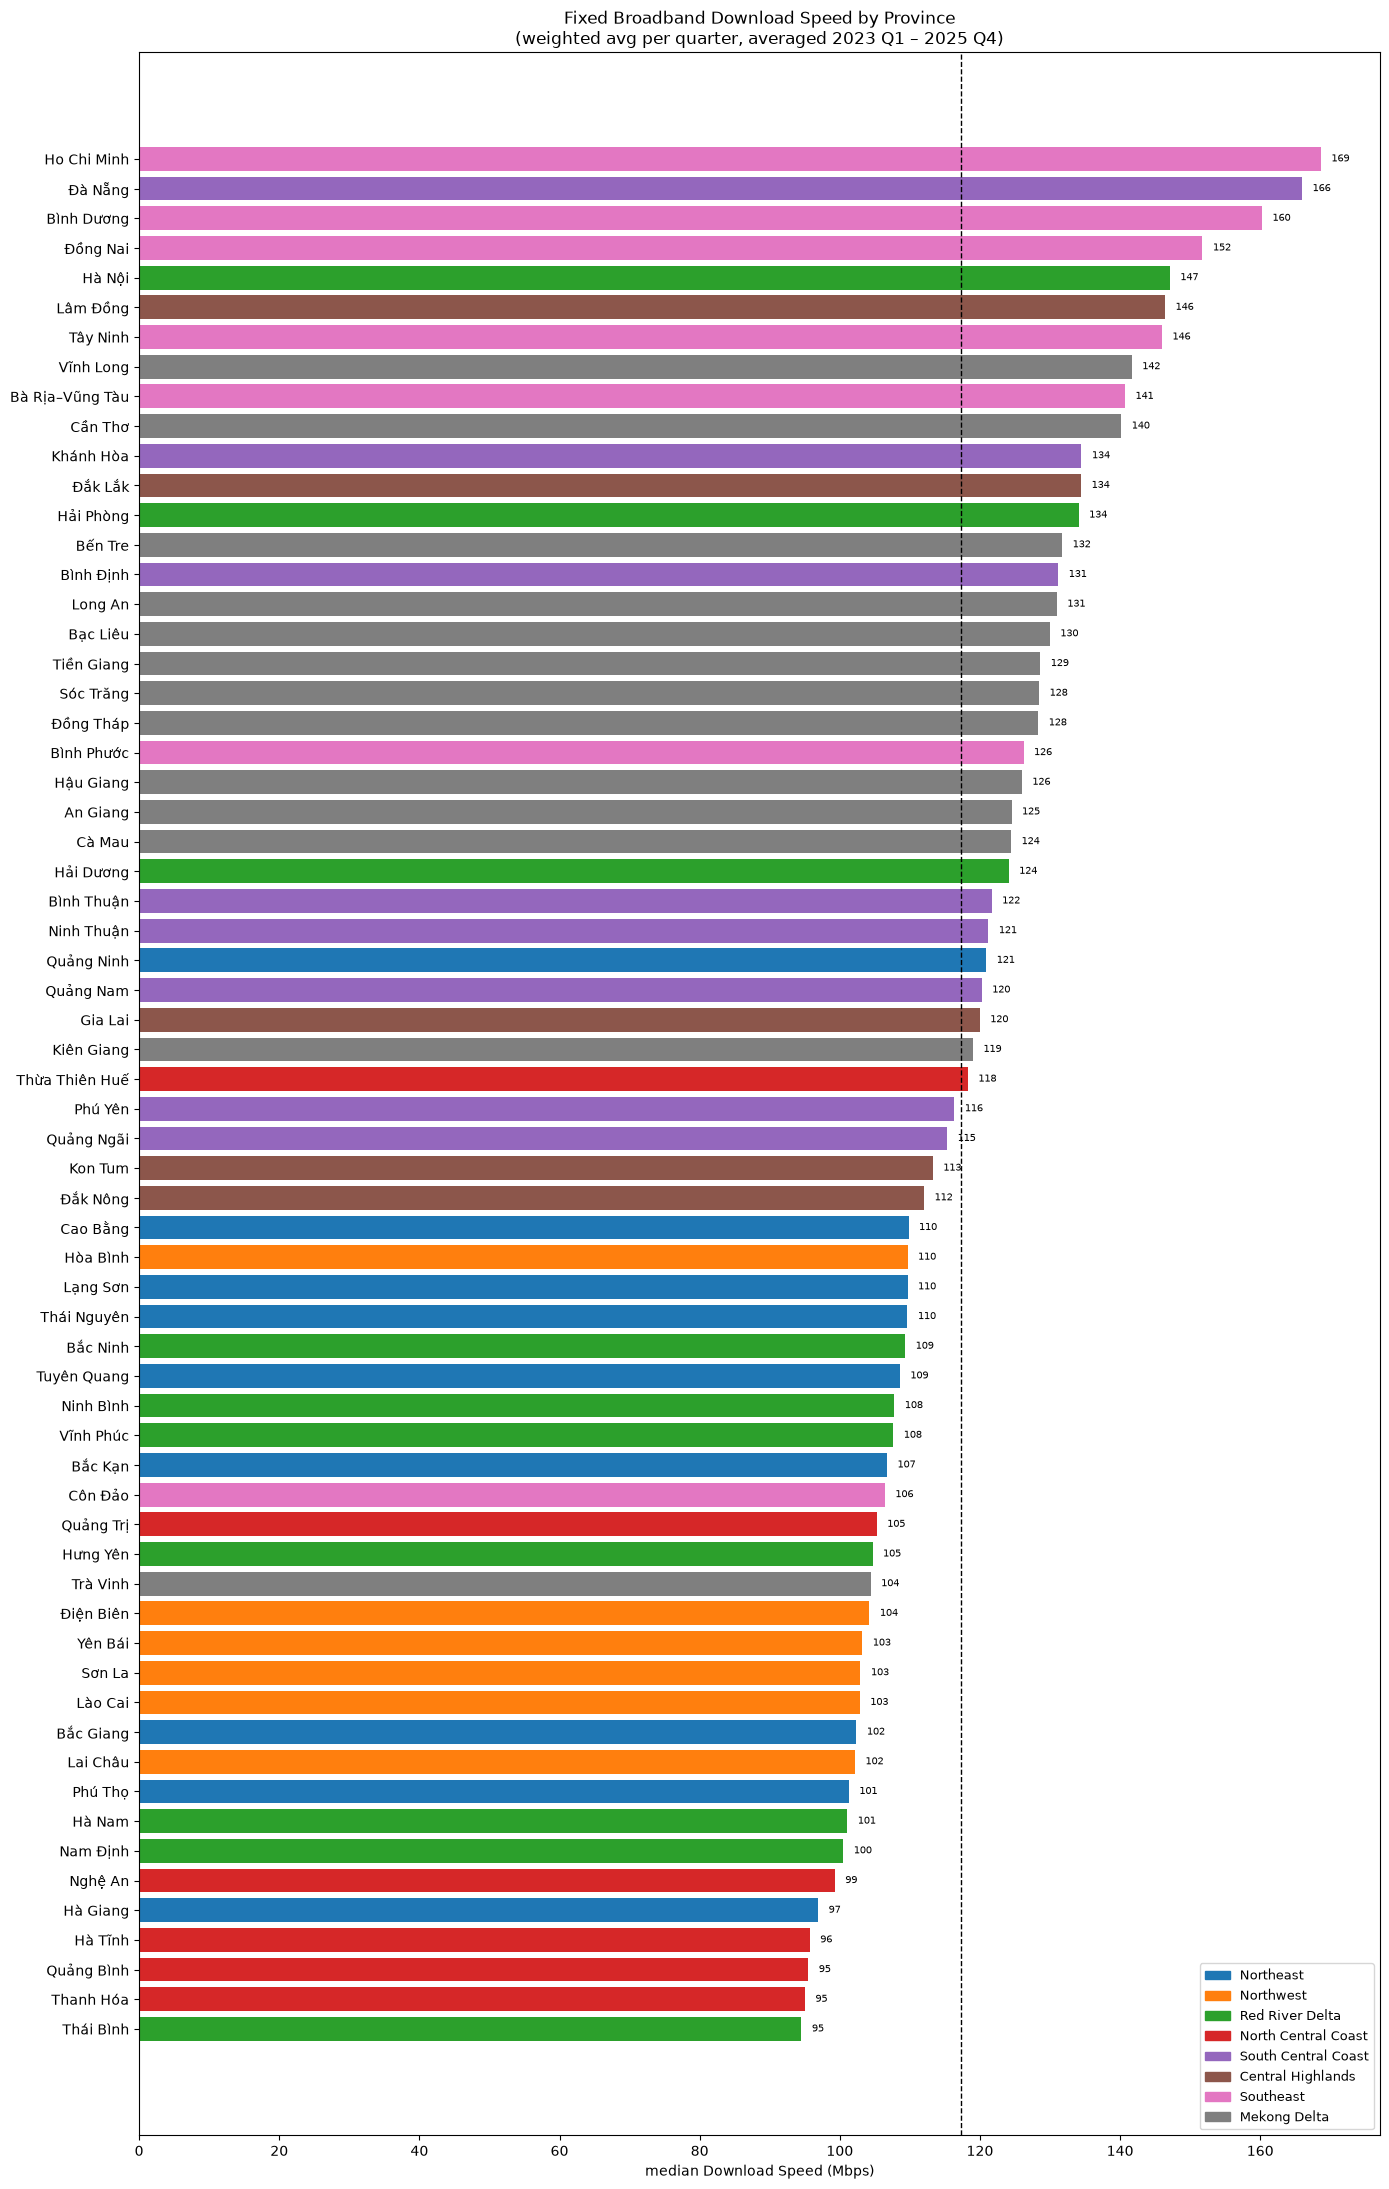

In [26]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

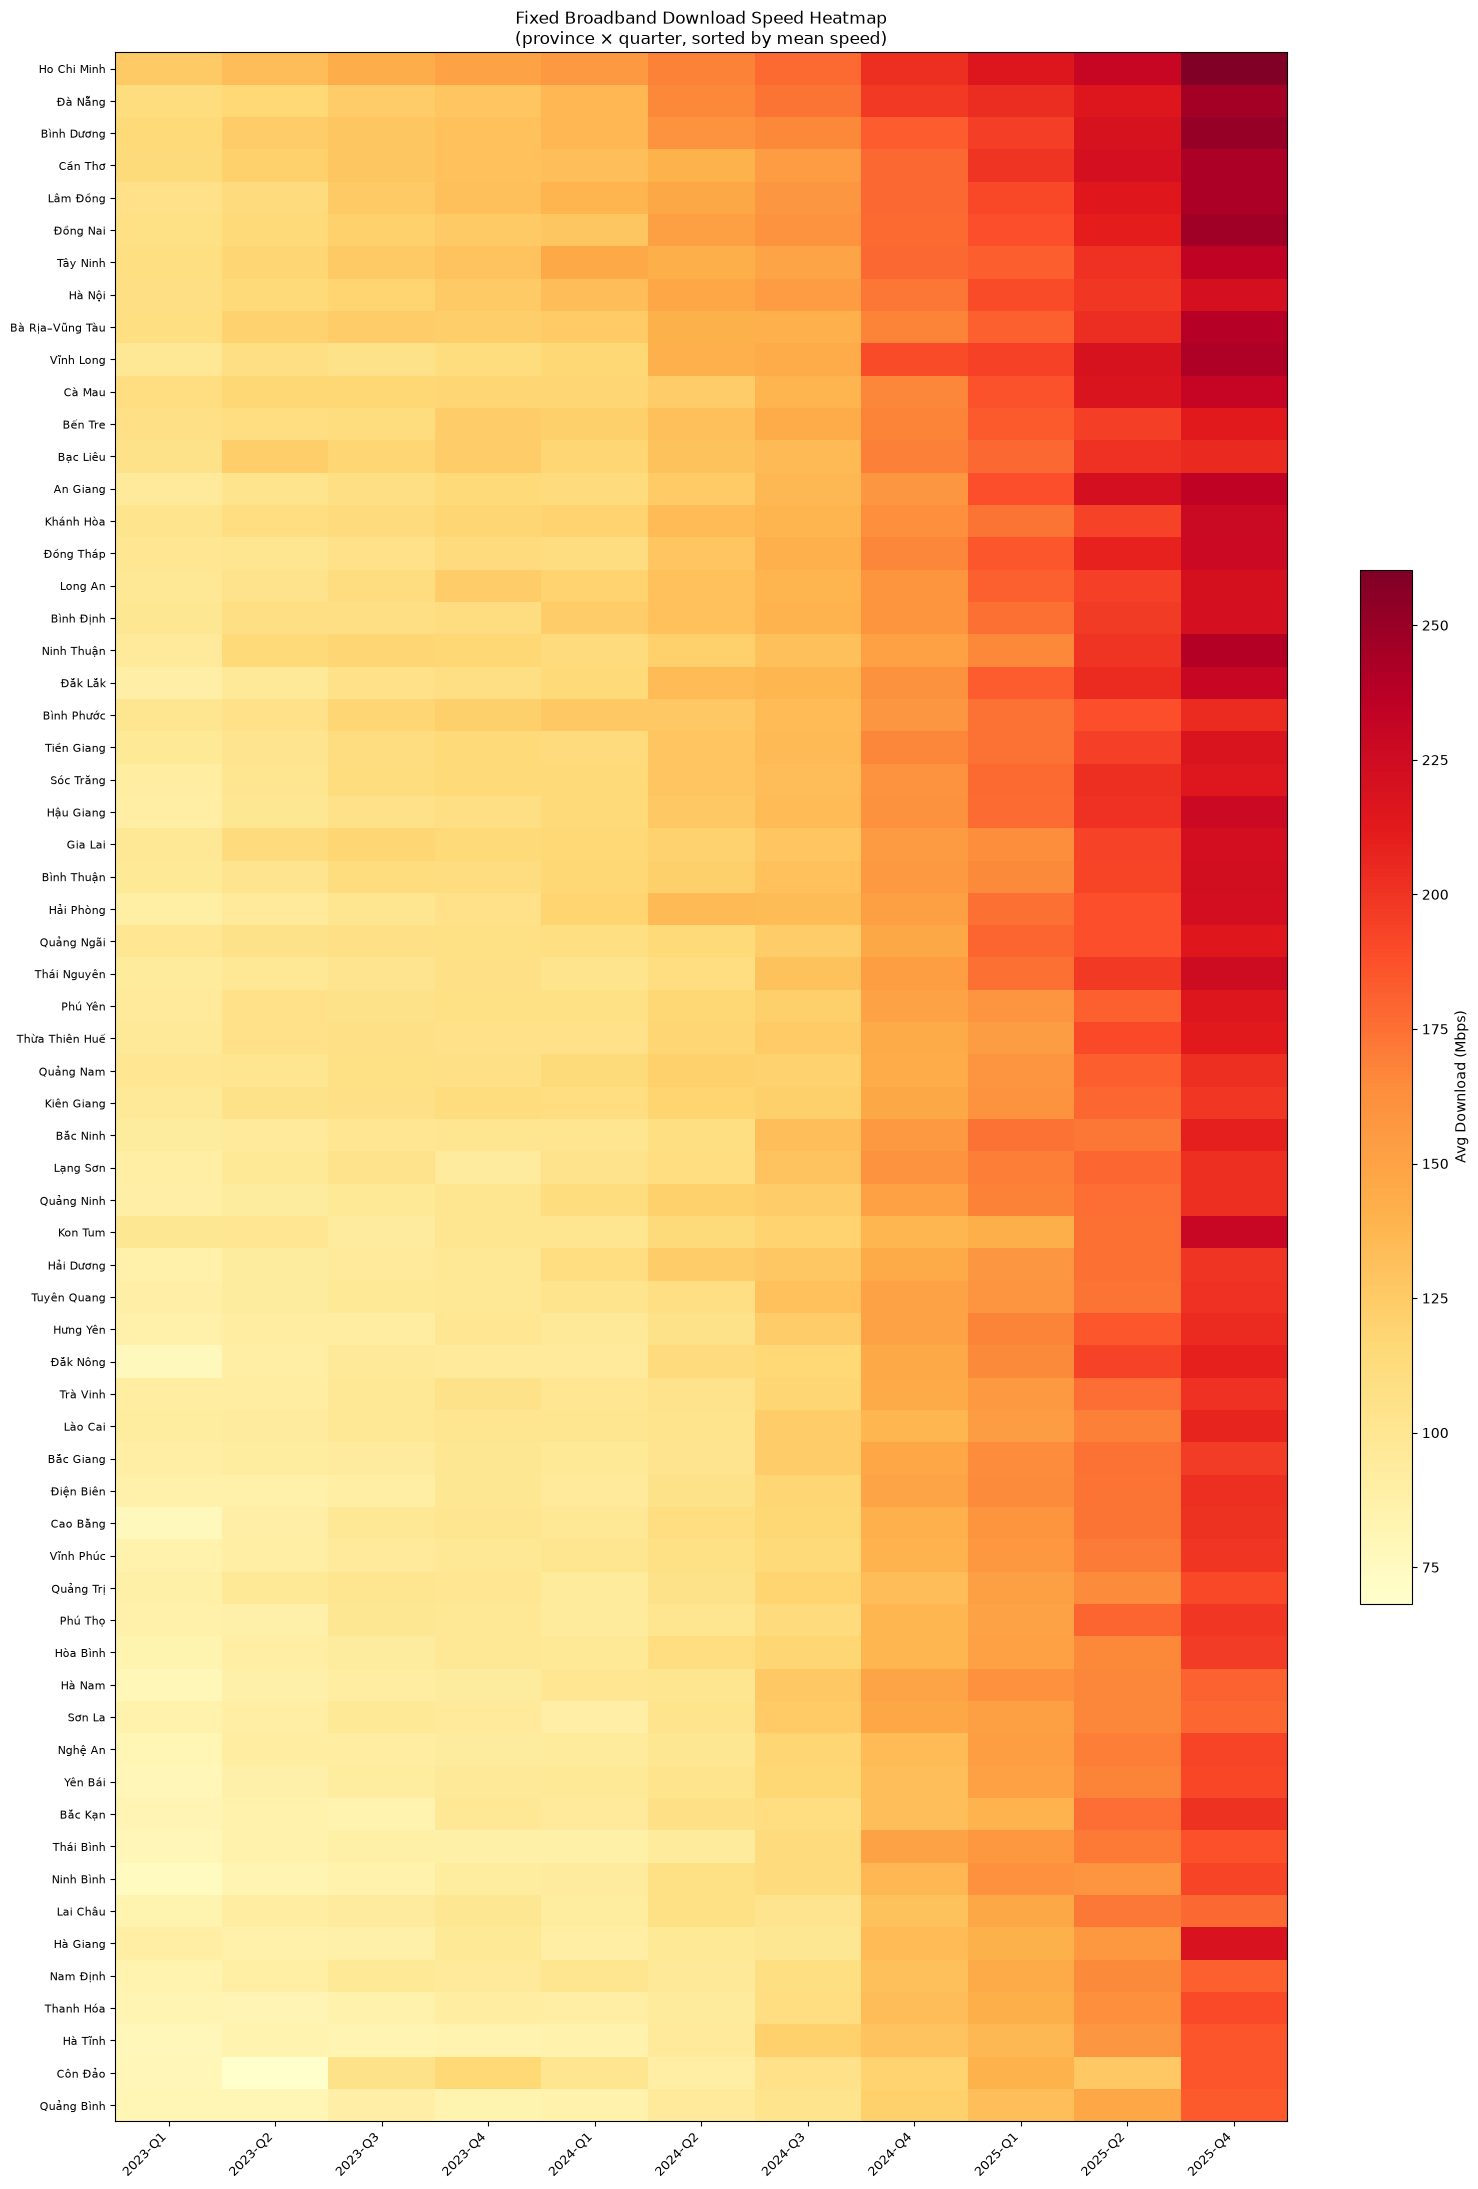

In [27]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

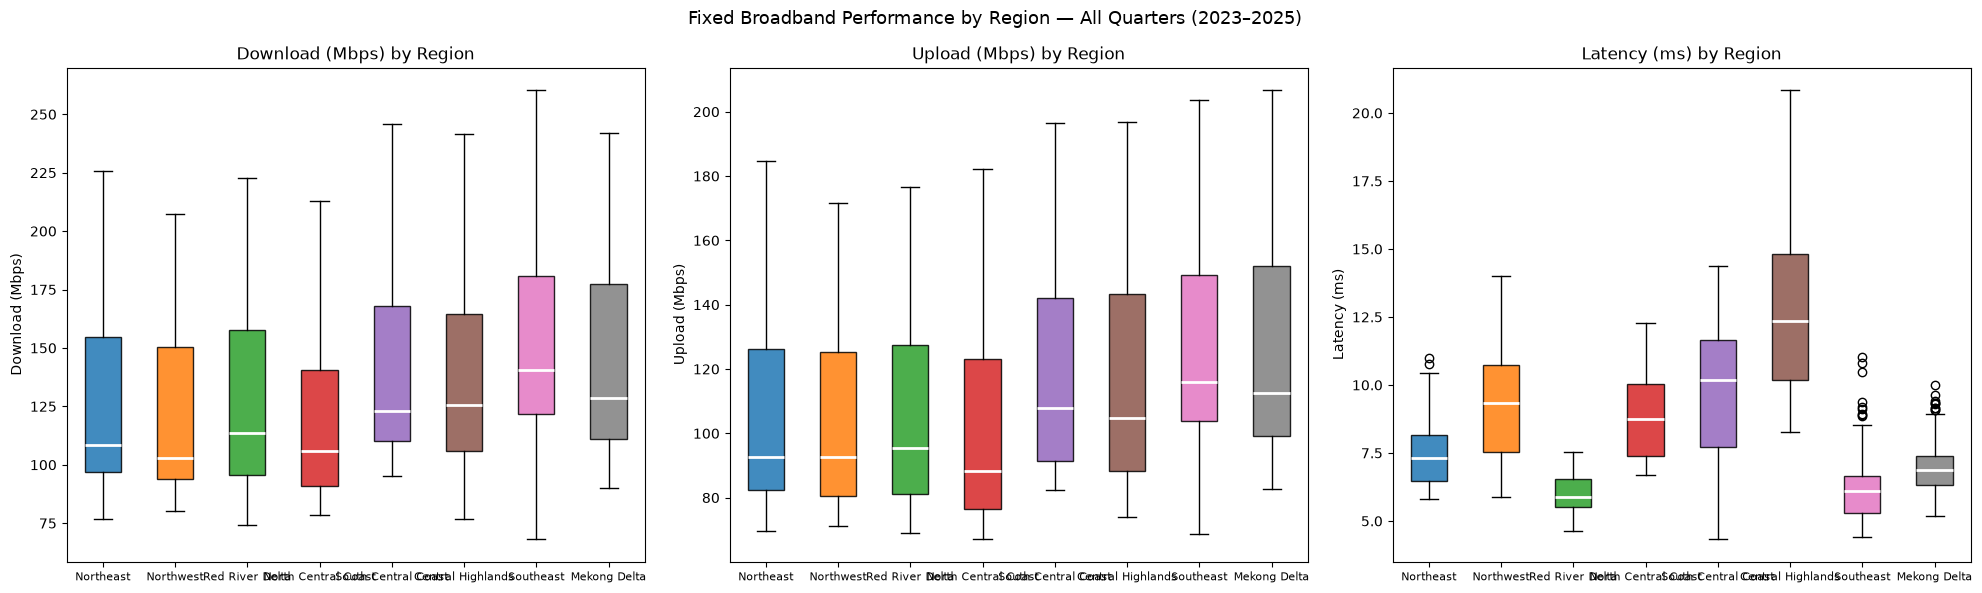

In [28]:
region_order = ['Northeast', 'Northwest', 'Red River Delta', 'North Central Coast', 'South Central Coast', 'Central Highlands', 'Southeast', 'Mekong Delta']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

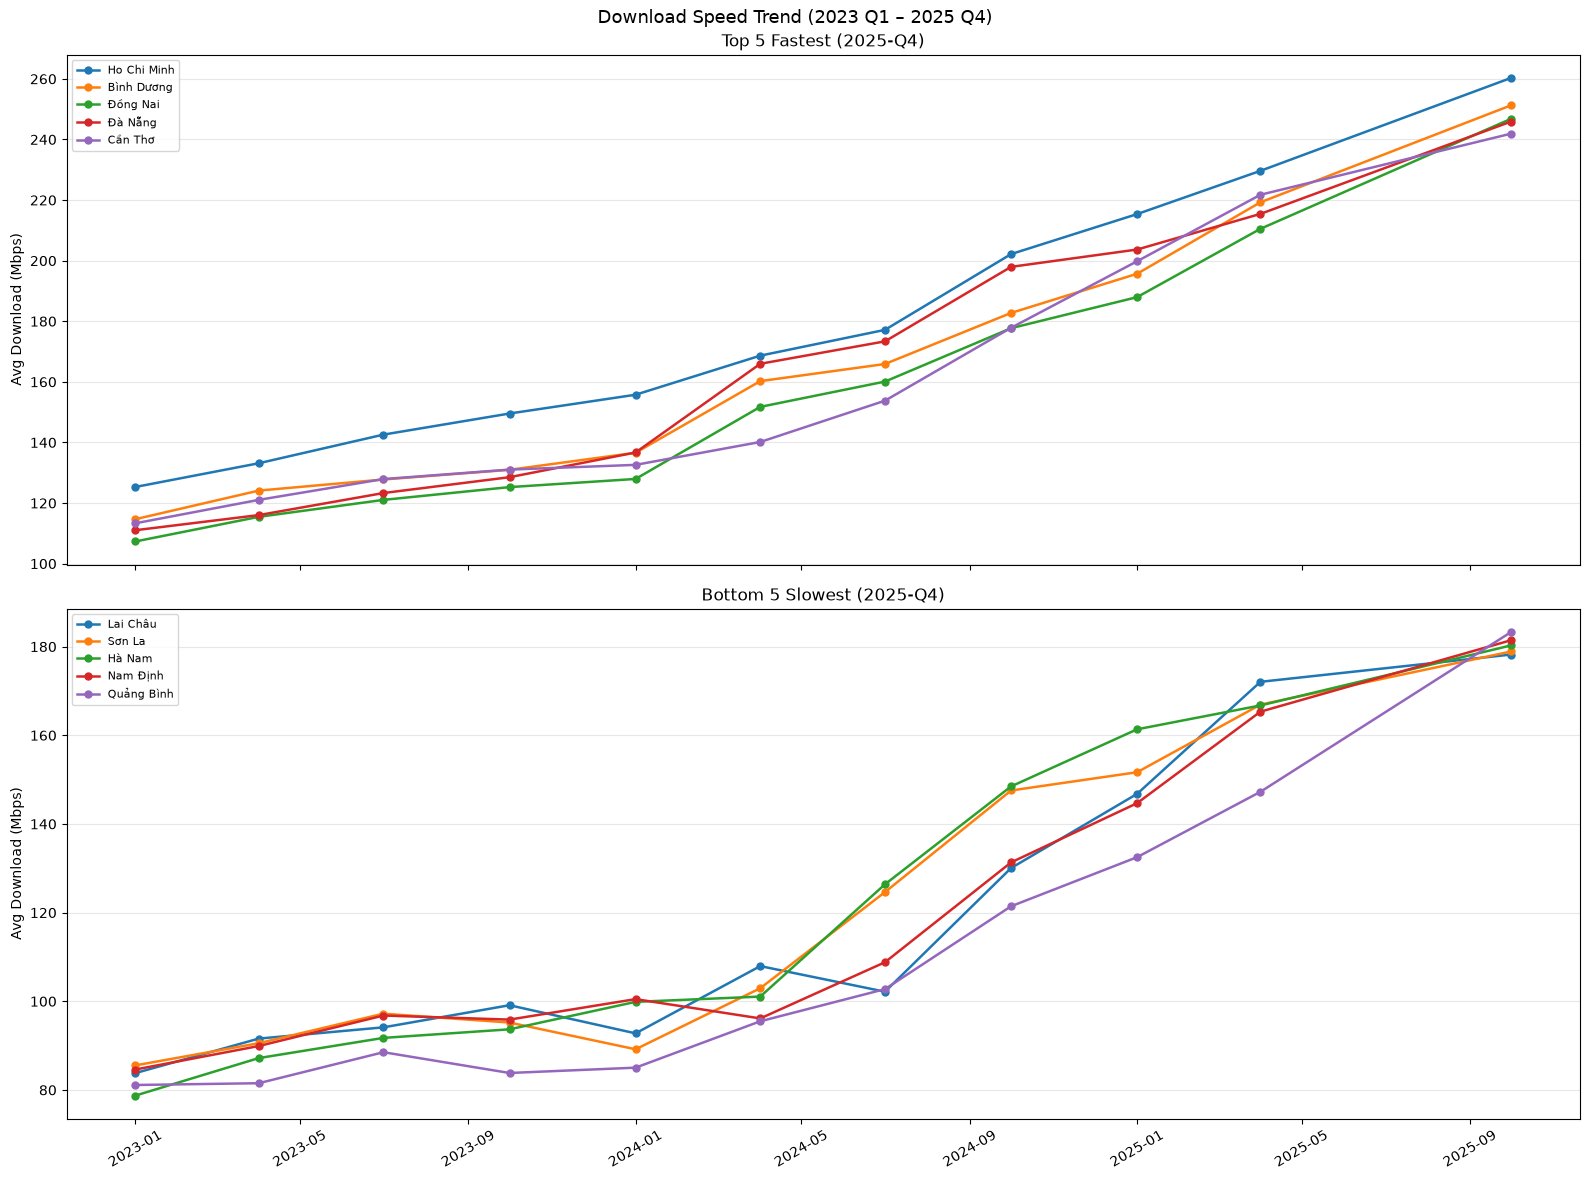

In [29]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

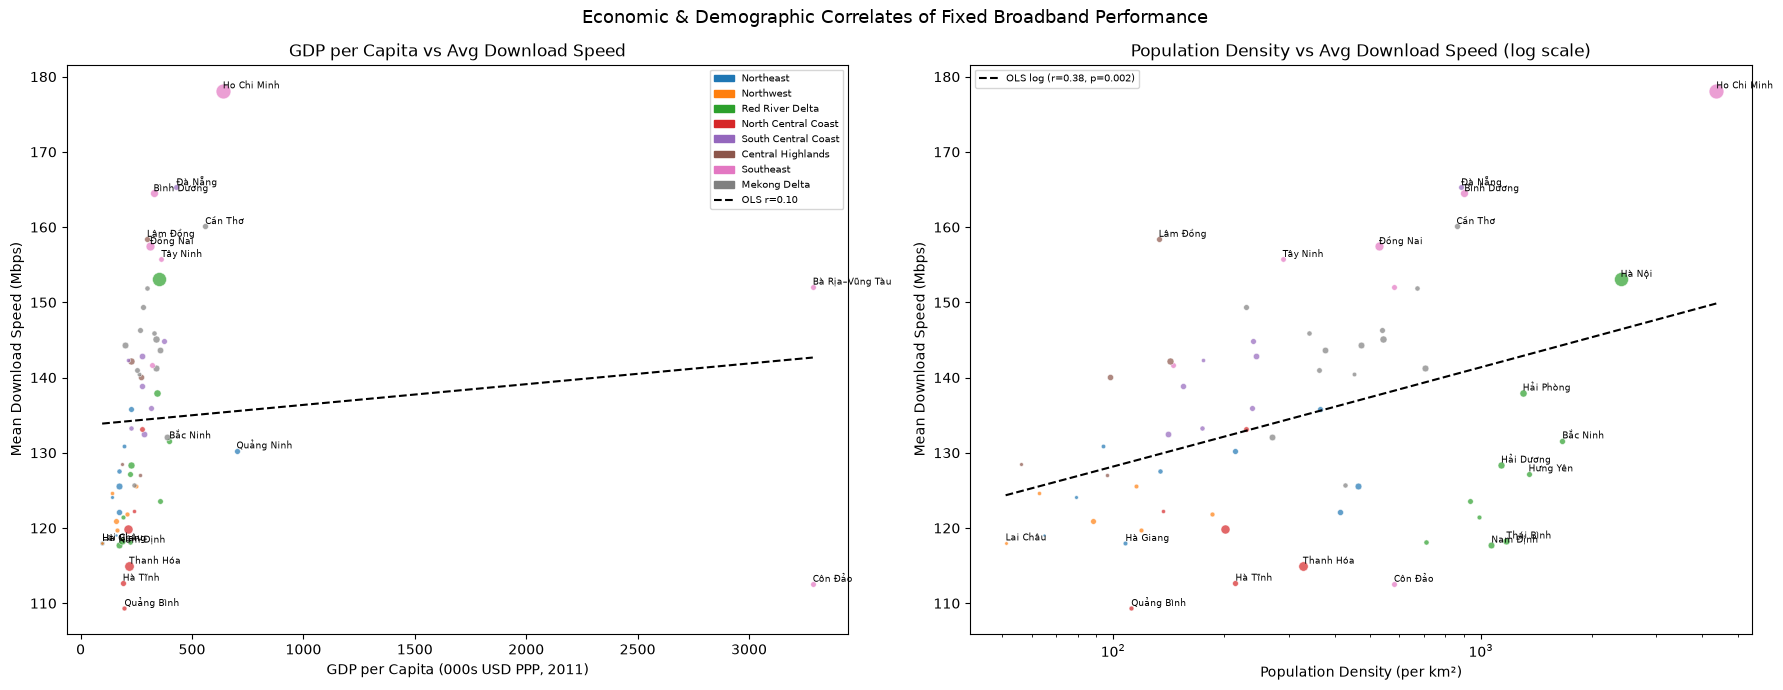

Pearson r (GDP vs download):     0.100  p=0.4309
Pearson r (log density vs download): 0.384  p=0.0017


In [30]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD PPP, 2011)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [31]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     13.13
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.03e-11
Time:                        19:55:00   Log-Likelihood:                -217.90
No. Observations:                  64   AIC:                             461.8
Df Residuals:                      51   BIC:                             489.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

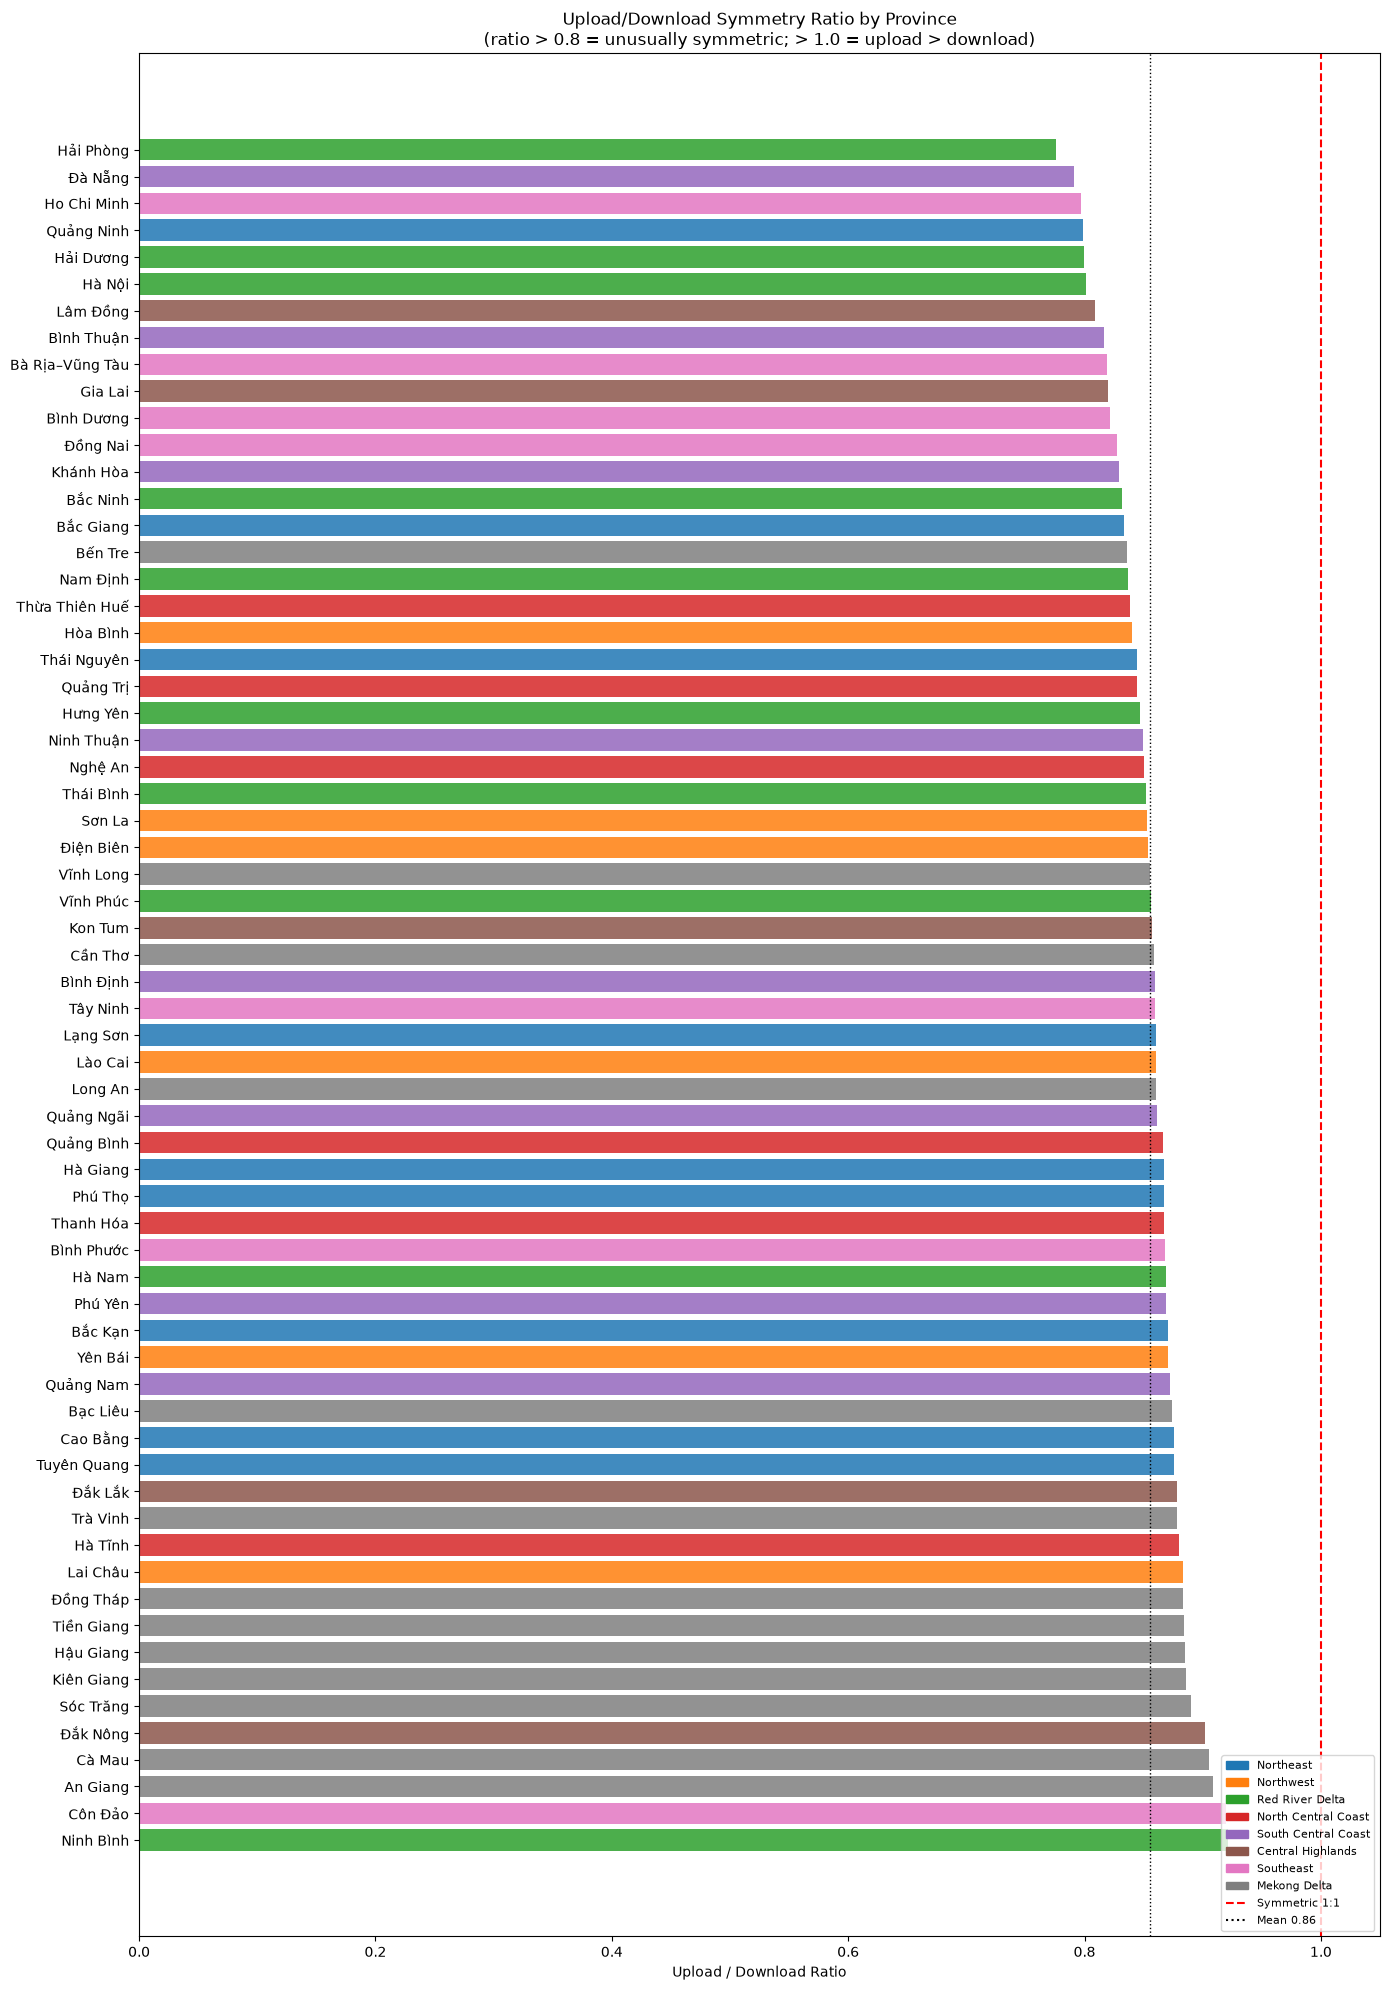

Provinces with UL/DL ratio > 0.8 (59):
           name              region  ul_dl_ratio
      Ninh Bình     Red River Delta     0.921448
        Côn Đảo           Southeast     0.919739
       An Giang        Mekong Delta     0.908746
         Cà Mau        Mekong Delta     0.904941
       Đắk Nông   Central Highlands     0.901805
      Sóc Trăng        Mekong Delta     0.890303
     Kiên Giang        Mekong Delta     0.886256
      Hậu Giang        Mekong Delta     0.885371
     Tiền Giang        Mekong Delta     0.884255
      Đồng Tháp        Mekong Delta     0.883018
       Lai Châu           Northwest     0.882927
        Hà Tĩnh North Central Coast     0.879890
       Trà Vinh        Mekong Delta     0.878449
        Đắk Lắk   Central Highlands     0.878305
    Tuyên Quang           Northeast     0.875961
       Cao Bằng           Northeast     0.875634
       Bạc Liêu        Mekong Delta     0.874037
      Quảng Nam South Central Coast     0.871997
        Yên Bái           Nort

In [32]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [33]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [34]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

           name              region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
    Ho Chi Minh           Southeast              1   178.16   141.25      4.65         0.80   475320.45                638474.09
        Đà Nẵng South Central Coast              1   165.27   130.59      4.82         0.79    65179.64                429834.96
     Bình Dương           Southeast              2   164.48   134.32      5.14         0.82    61850.09                327276.61
        Cần Thơ        Mekong Delta              1   160.11   136.76      6.17         0.86    32243.09                559273.75
       Lâm Đồng   Central Highlands              2   158.42   128.11     12.44         0.81    32938.73                297641.14
       Đồng Nai           Southeast              2   157.45   129.33      5.81         0.83    77776.73                311341.31
       Tây Ninh           Southeast              1   155.74   133.35      6.51         0.86    19

### 13. UL/DL Symmetry — Fiber Penetration Evidence

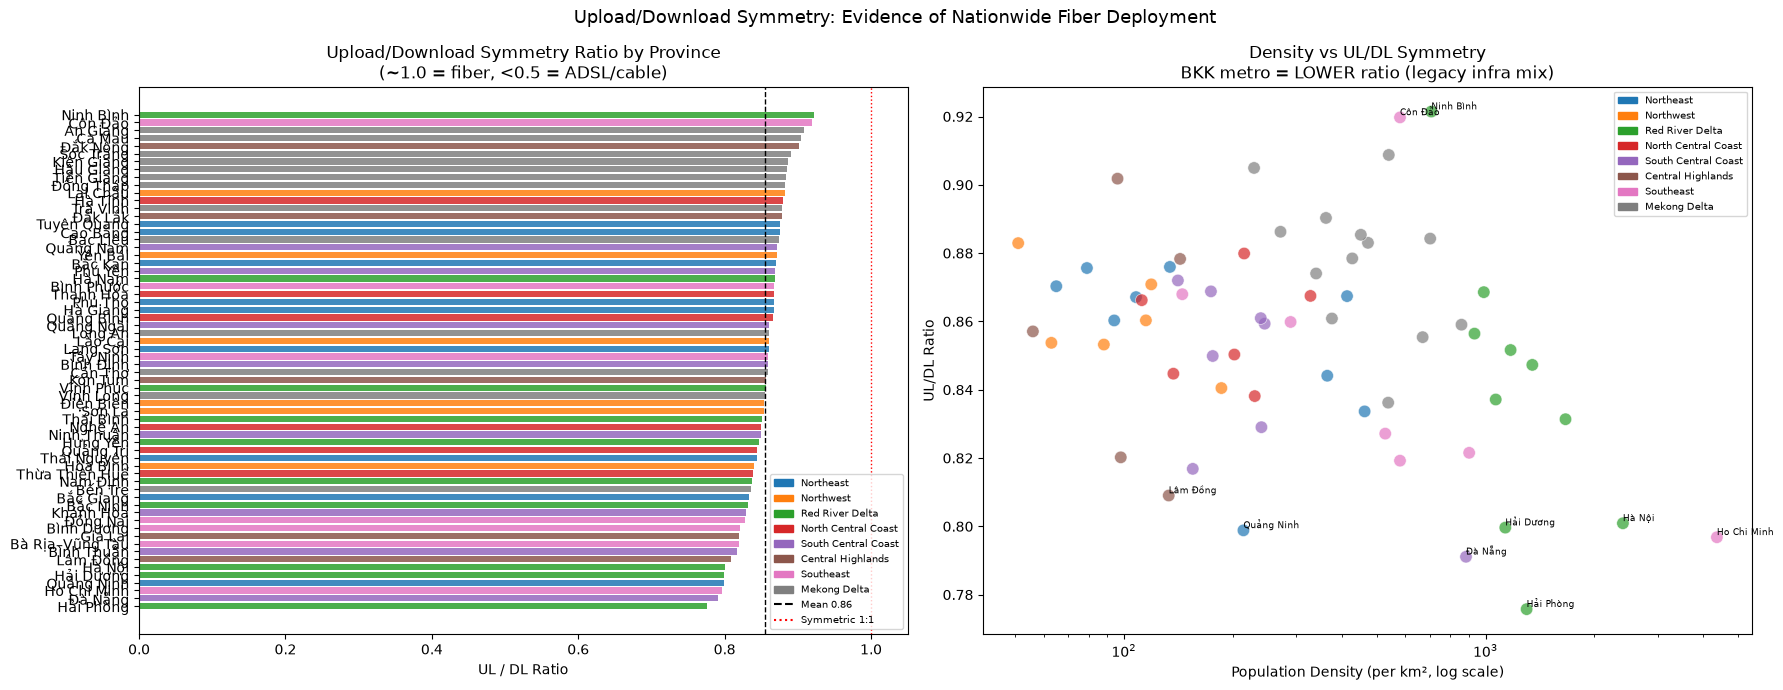

Provinces ratio > 0.90: 5 (near-perfect fiber)
Provinces ratio > 0.80: 59 out of 64
Southeast min ratio: 0.797
Northwest max ratio: 0.883


In [35]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nBKK metro = LOWER ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

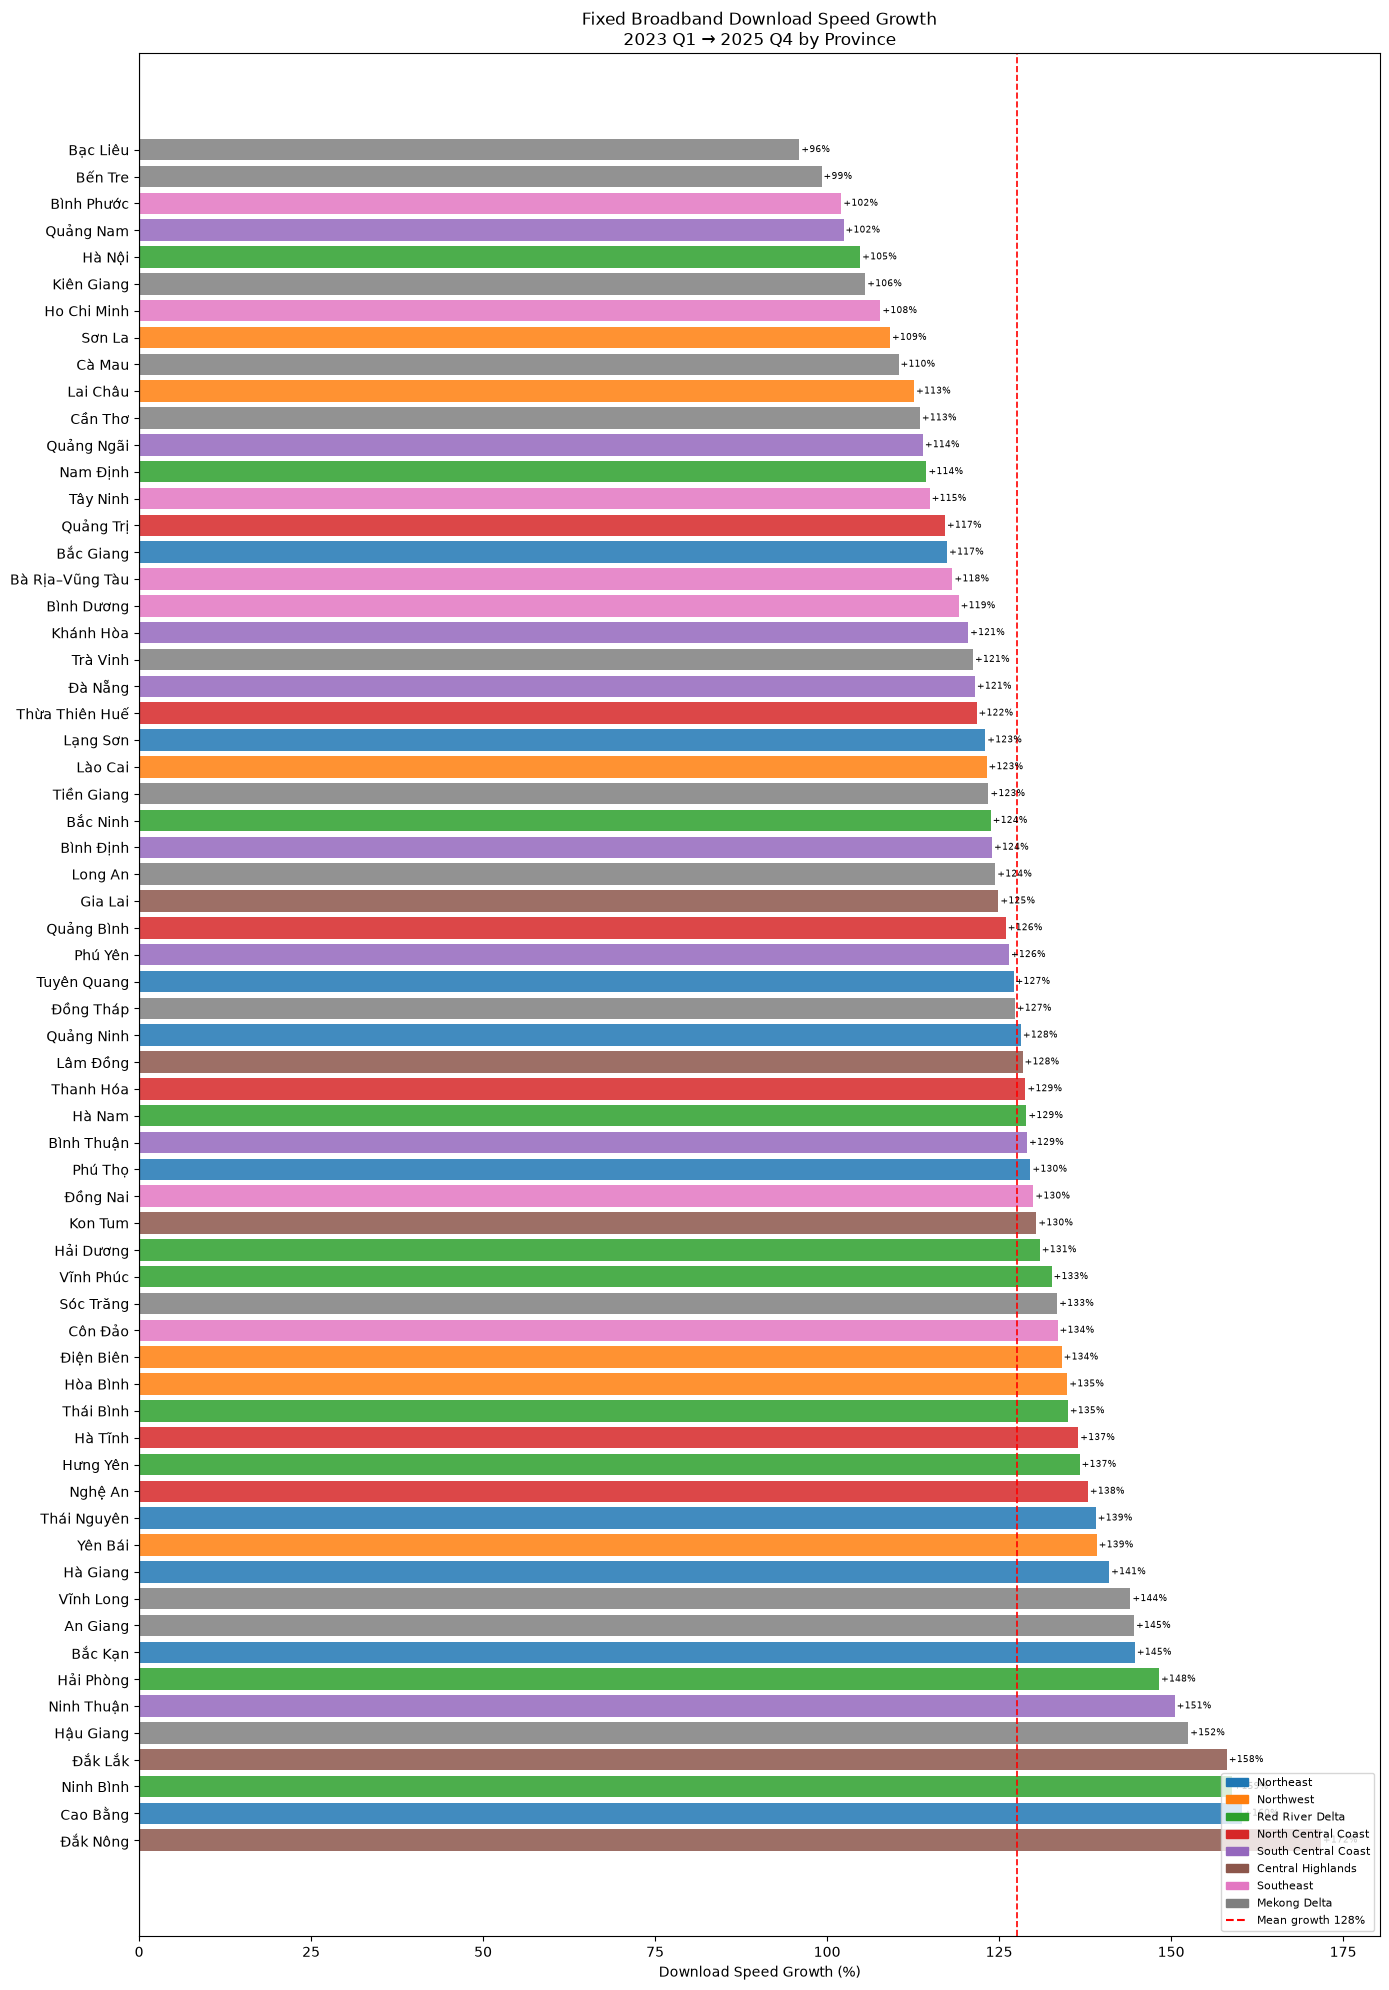

Top 10 fastest growing provinces:
      name              region  internet_tier  pct_growth
  Đắk Nông   Central Highlands              2  171.771852
  Cao Bằng           Northeast              4  160.315148
 Ninh Bình     Red River Delta              3  158.788652
   Đắk Lắk   Central Highlands              3  158.098960
 Hậu Giang        Mekong Delta              2  152.492535
Ninh Thuận South Central Coast              3  150.522101
 Hải Phòng     Red River Delta              1  148.248855
   Bắc Kạn           Northeast              4  144.731457
  An Giang        Mekong Delta              1  144.613240
 Vĩnh Long        Mekong Delta              2  144.088437

Bottom 5 (slowest growth or decline):
      name              region  internet_tier  pct_growth
  Bạc Liêu        Mekong Delta              2   95.966942
   Bến Tre        Mekong Delta              2   99.187613
Bình Phước           Southeast              2  102.078209
 Quảng Nam South Central Coast              2  102.383779

In [36]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [37]:
# ── Export Ookla quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_vietnam_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 704 rows → ../../data/exports/ookla_vietnam_province_quarterly.csv
          province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable        region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0         An Giang  2023-Q1  2023        1   95.579586   88.105158       7.184658      18889.0   2010.0         True  Mekong Delta              1   2057000                338704.14              540
1  Bà Rịa–Vũng Tàu  2023-Q1  2023        1  109.294430   94.016531       5.925378      31961.0   1504.0         True     Southeast              1   1303000               3286254.54              580
2       Bình Dương  2023-Q1  2023        1  114.679848  101.532764       4.780367      53817.0   2251.0         True     Southeast              2   2564000                327276.61              901


---
# Part 2 — Mobile/Cellular


## Full EDA — Ookla Mobile/Cellular, Vietnam (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [38]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/vietnam_provinces.geojson'
PROV_REF    = '../../data/reference/vietnam_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_mobile_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*mobile_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):  104,657 raw tiles → 64 provinces


  2023-Q2 (2023-04-01):  104,719 raw tiles → 64 provinces


  2023-Q3 (2023-07-01):  105,329 raw tiles → 64 provinces


  2023-Q4 (2023-10-01):  112,750 raw tiles → 64 provinces


  2024-Q1 (2024-01-01):  106,681 raw tiles → 64 provinces


...

  2024-Q4 (2024-10-01):   96,338 raw tiles → 64 provinces


  2025-Q1 (2025-01-01):   88,661 raw tiles → 64 provinces


  2025-Q2 (2025-04-01):   89,094 raw tiles → 64 provinces


  2025-Q3 (2025-07-01):   81,122 raw tiles → 64 provinces


  2025-Q4 (2025-10-01):   87,486 raw tiles → 64 provinces

Master shape: (768, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  64

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-07-01
  2025-10-01


In [39]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    63
2023-Q2    63
2023-Q3    64
2023-Q4    63
2024-Q1    63
2024-Q2    63
2024-Q3    63
2024-Q4    63
2025-Q1    63
2025-Q2    63
2025-Q3    63
2025-Q4    63

Overall reliable: 757 / 768 (98.6%)


### 2. Data Quality — Coverage per Province

In [40]:
# Expected: 77 provinces × 12 quarters = 924 rows
expected = 77 * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected_n} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 924 | Actual: 768 | Missing: 156



All 64 provinces covered in every quarter.

Low-test quarters (< 100 tests) — 11 cases:
   name   label  total_tests  n_tiles
Côn Đảo 2025-Q3         28.0     10.0
Côn Đảo 2024-Q3         35.0     15.0
Côn Đảo 2025-Q1         40.0     19.0
Côn Đảo 2023-Q2         58.0     20.0
Côn Đảo 2025-Q2         62.0     18.0
Côn Đảo 2024-Q1         64.0     18.0
Côn Đảo 2024-Q2         71.0     19.0
Côn Đảo 2023-Q1         76.0     20.0
Côn Đảo 2023-Q4         81.0     14.0
Côn Đảo 2025-Q4         88.0     12.0
Côn Đảo 2024-Q4         91.0     17.0


In [41]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 757 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

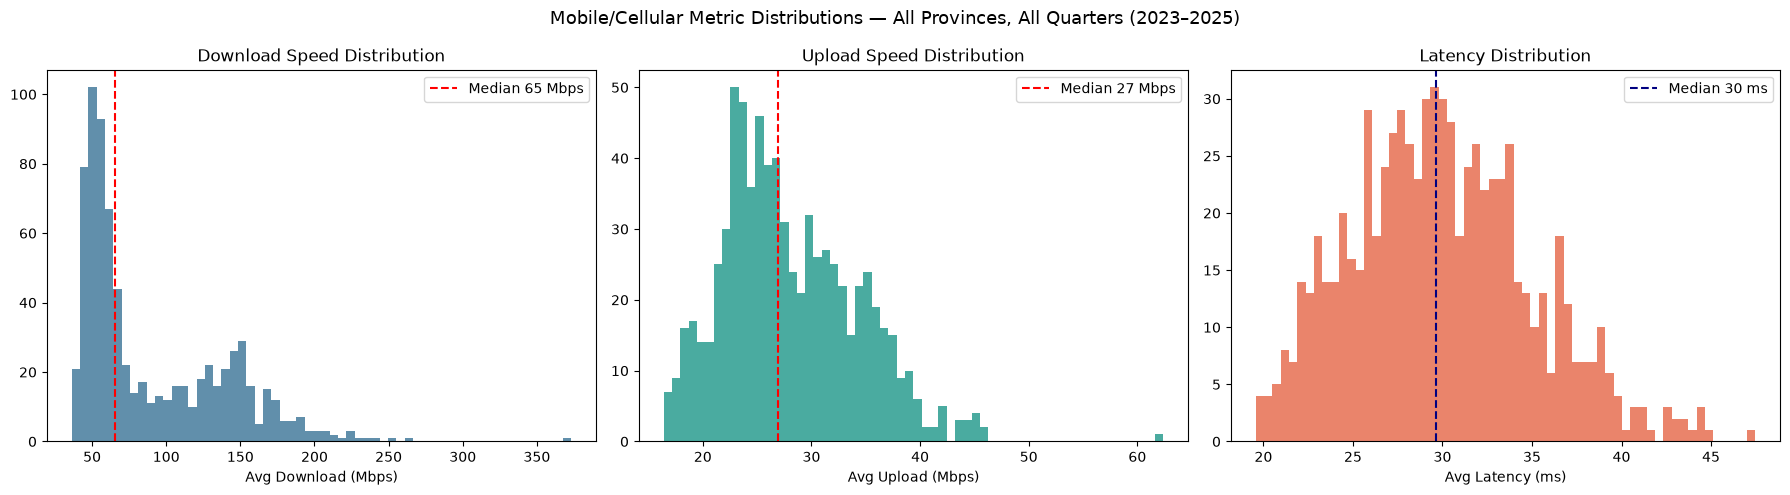

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      757.00      757.00         757.00       757.00
mean        90.41       28.00          29.94      4608.08
std         48.47        6.17           5.02      8289.16
min         36.23       16.40          19.57       126.00
25%         52.35       23.43          26.25      1792.00
50%         65.38       26.91          29.62      2847.00
75%        129.81       32.09          33.18      4262.00
max        373.03       62.36          47.46     70080.00


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

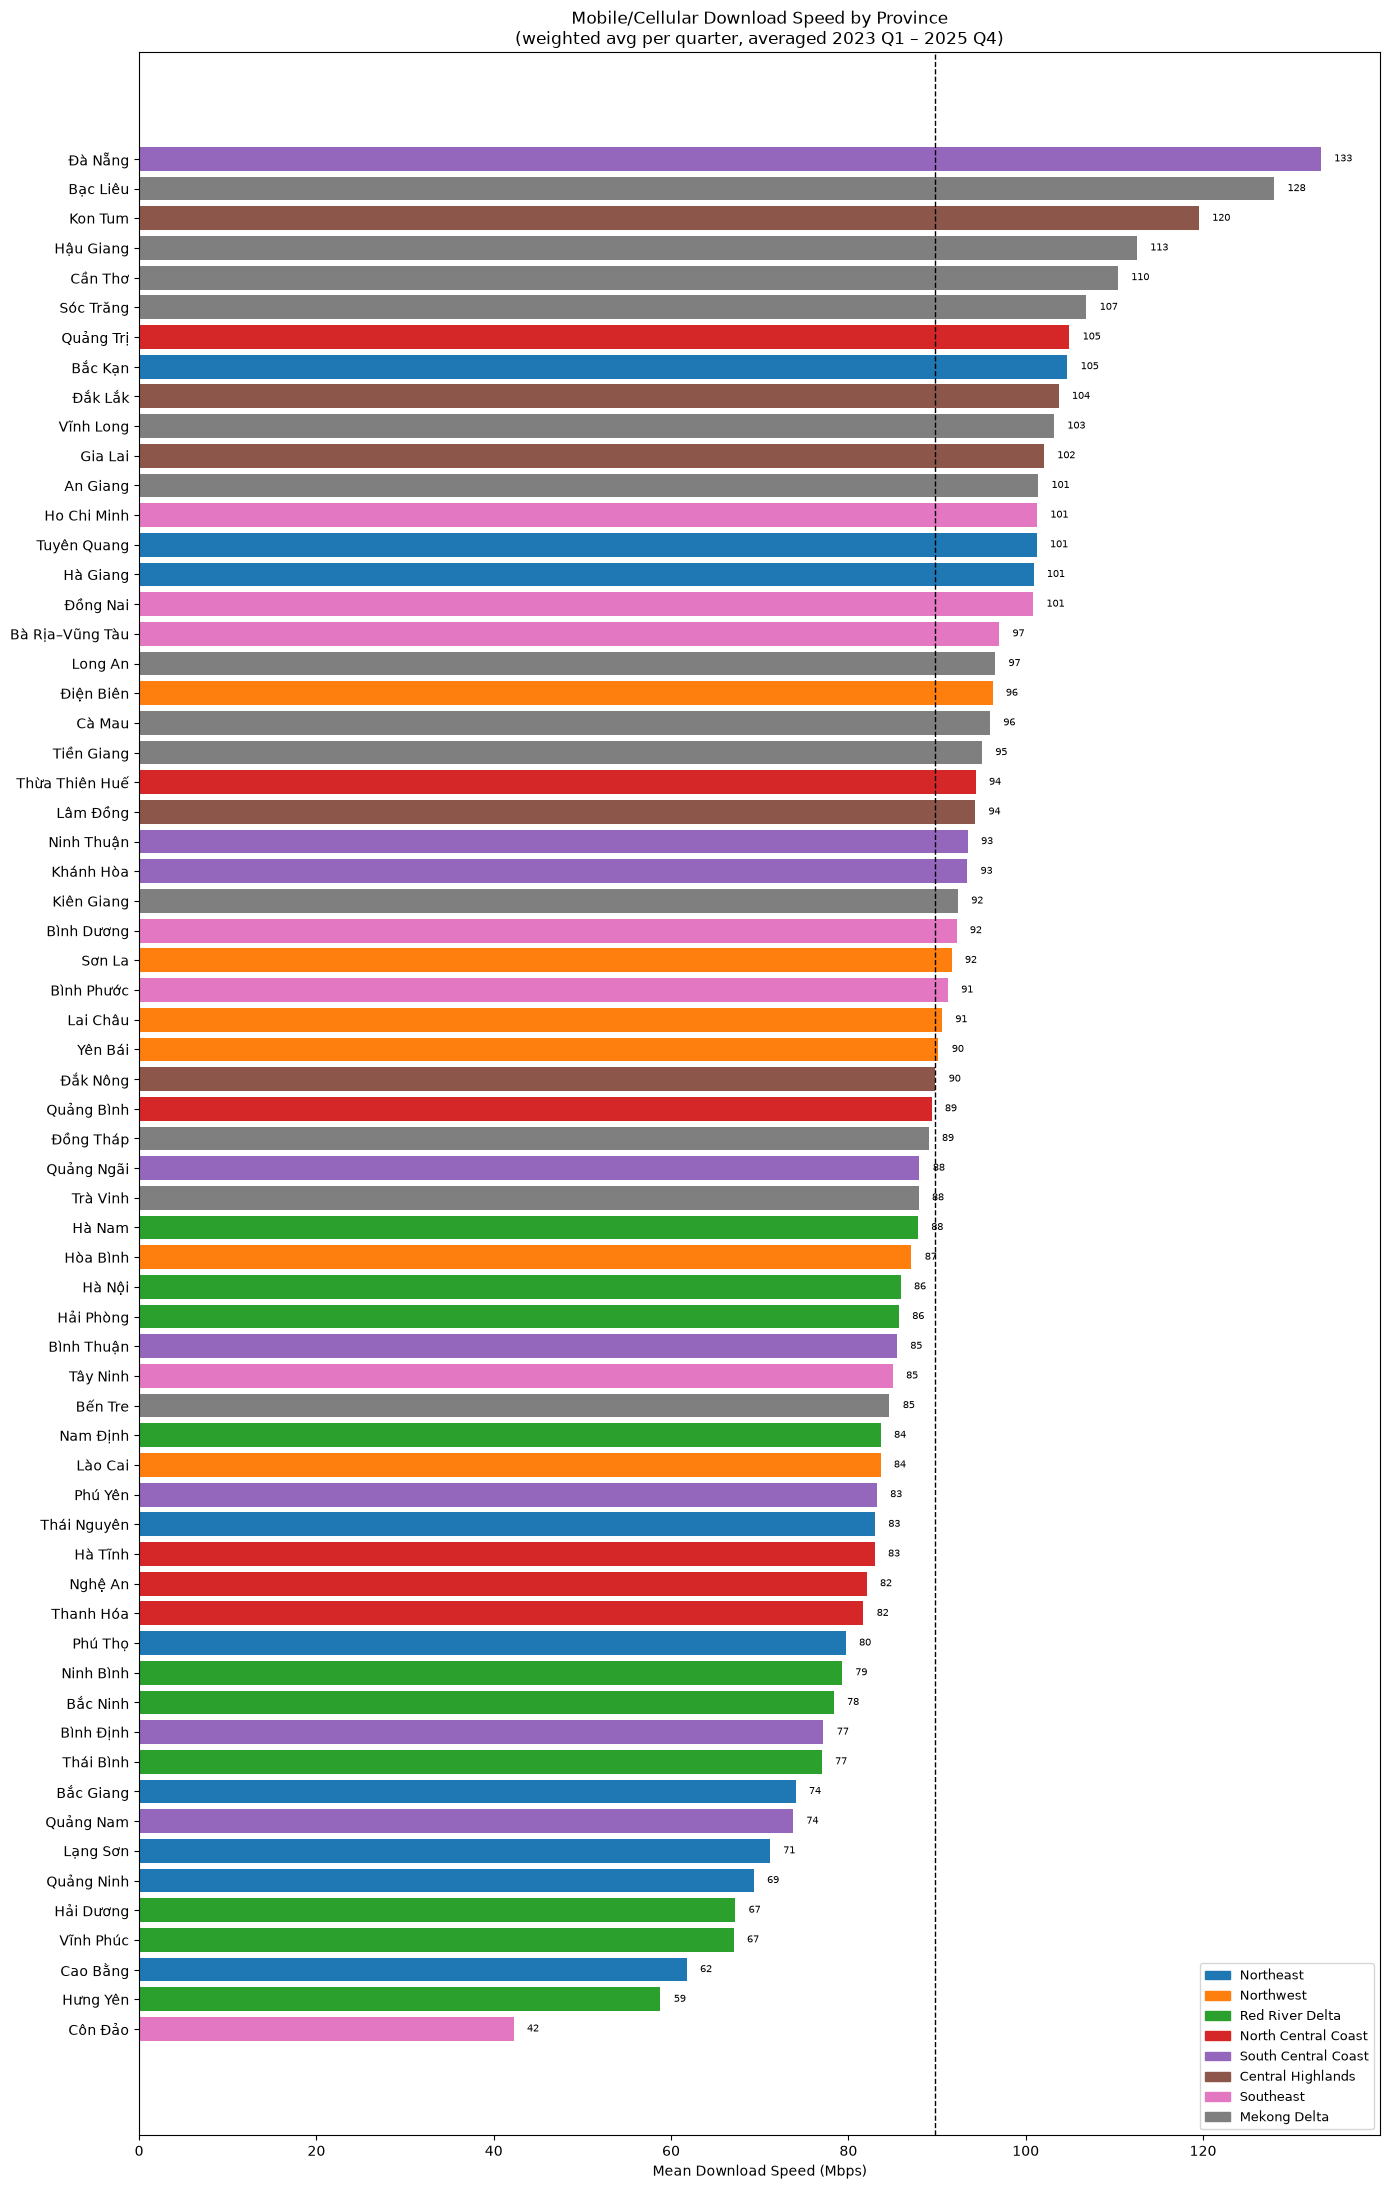

In [43]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

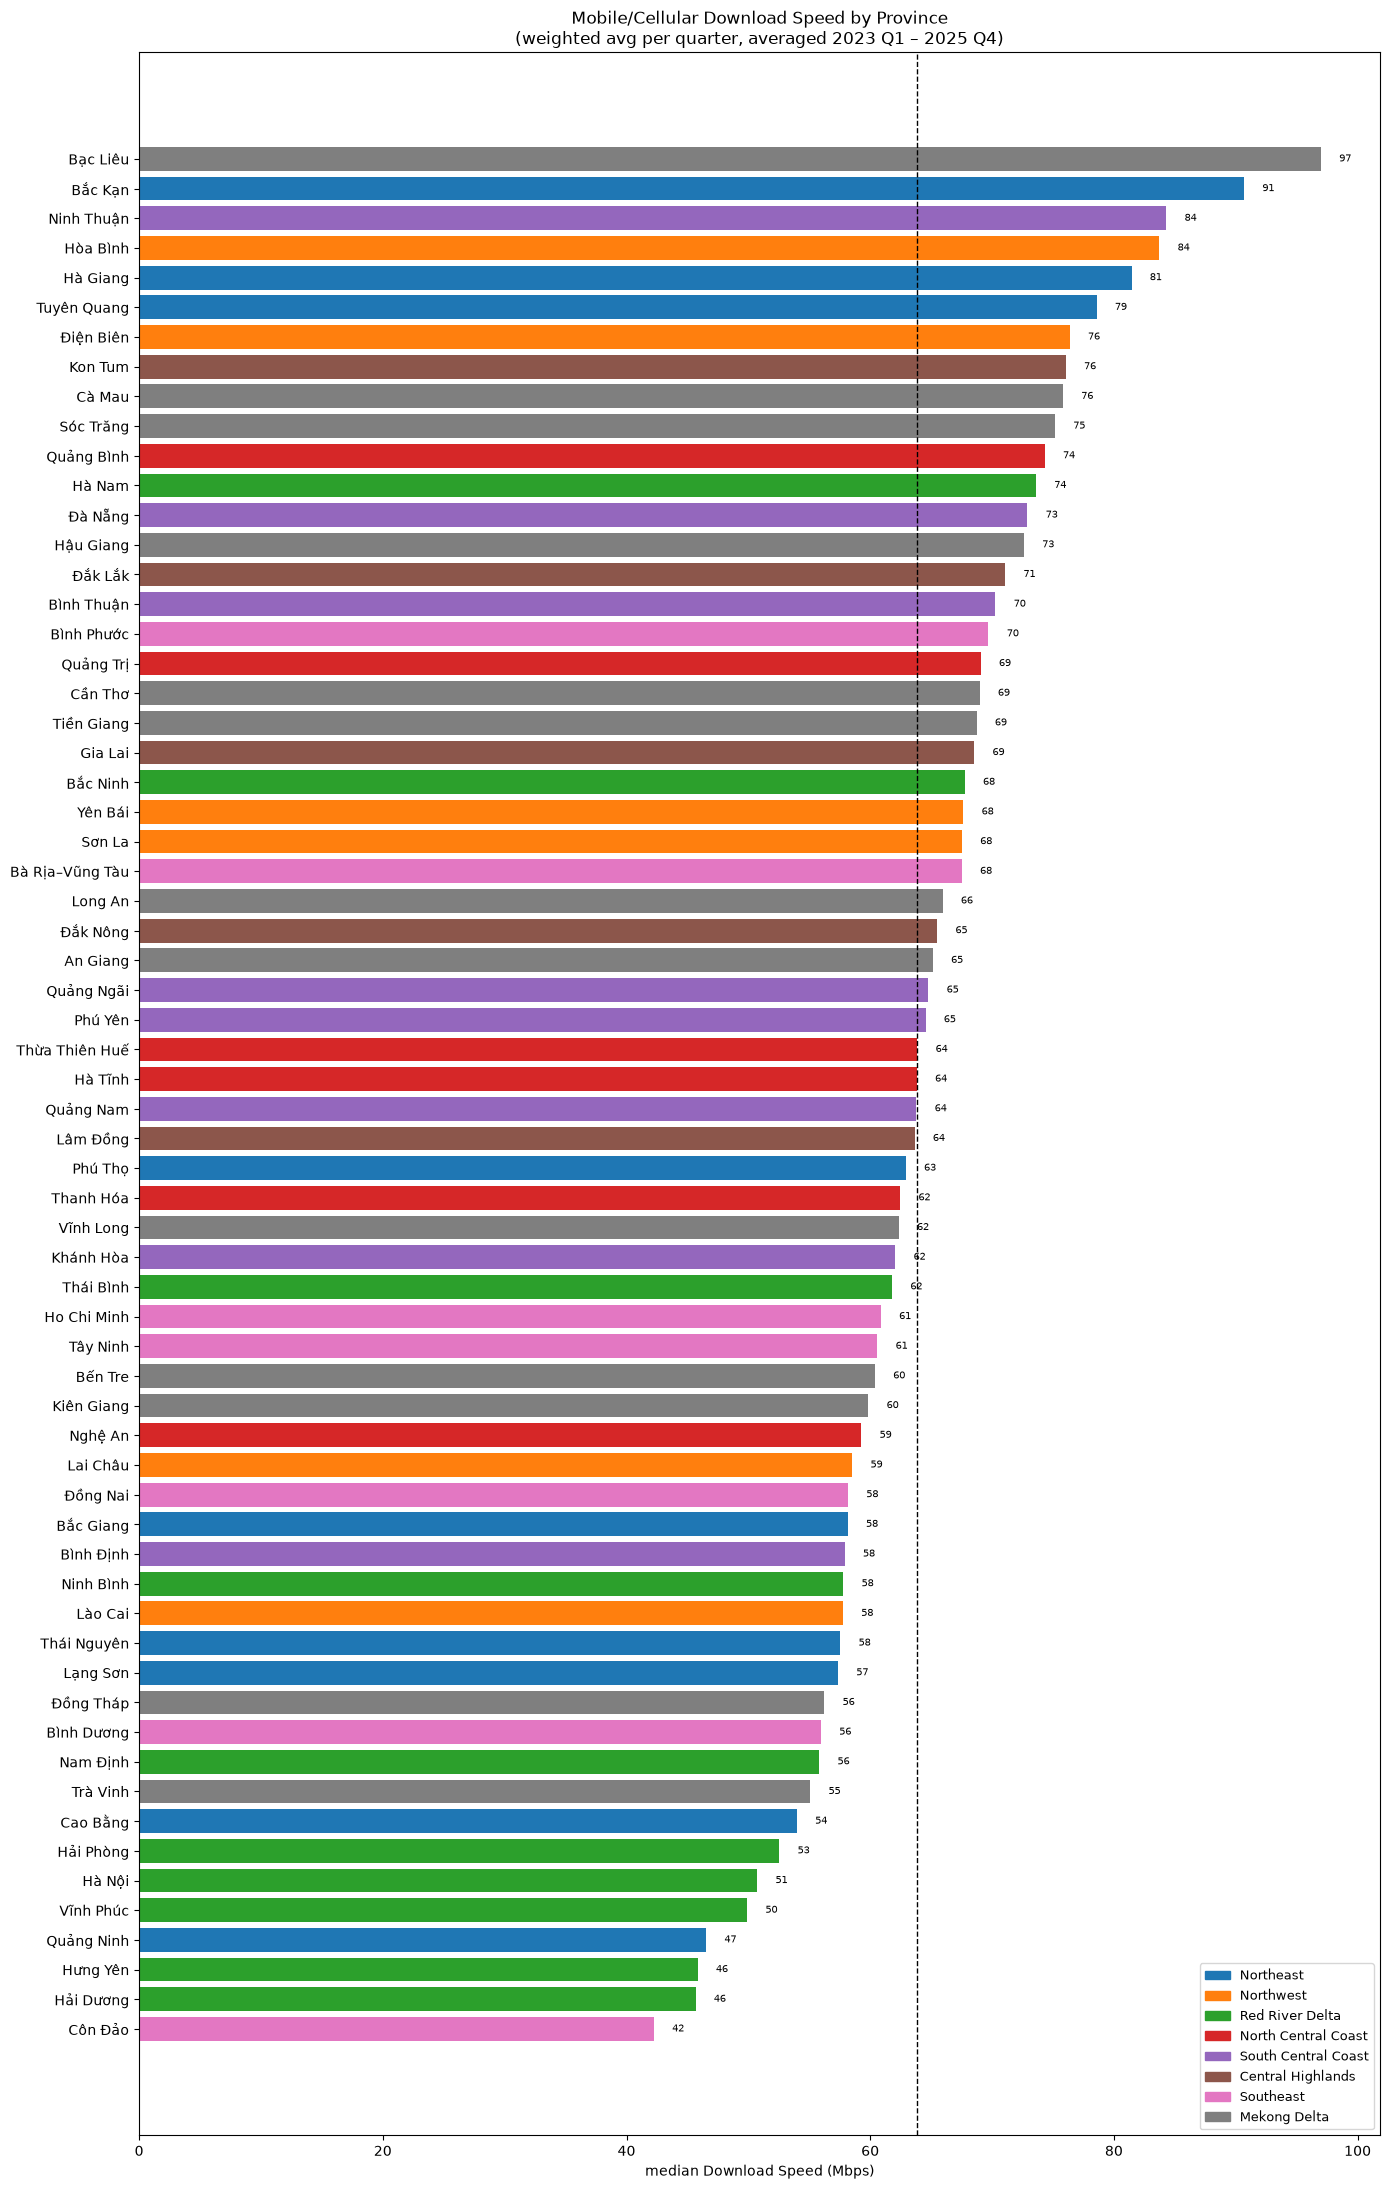

In [44]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

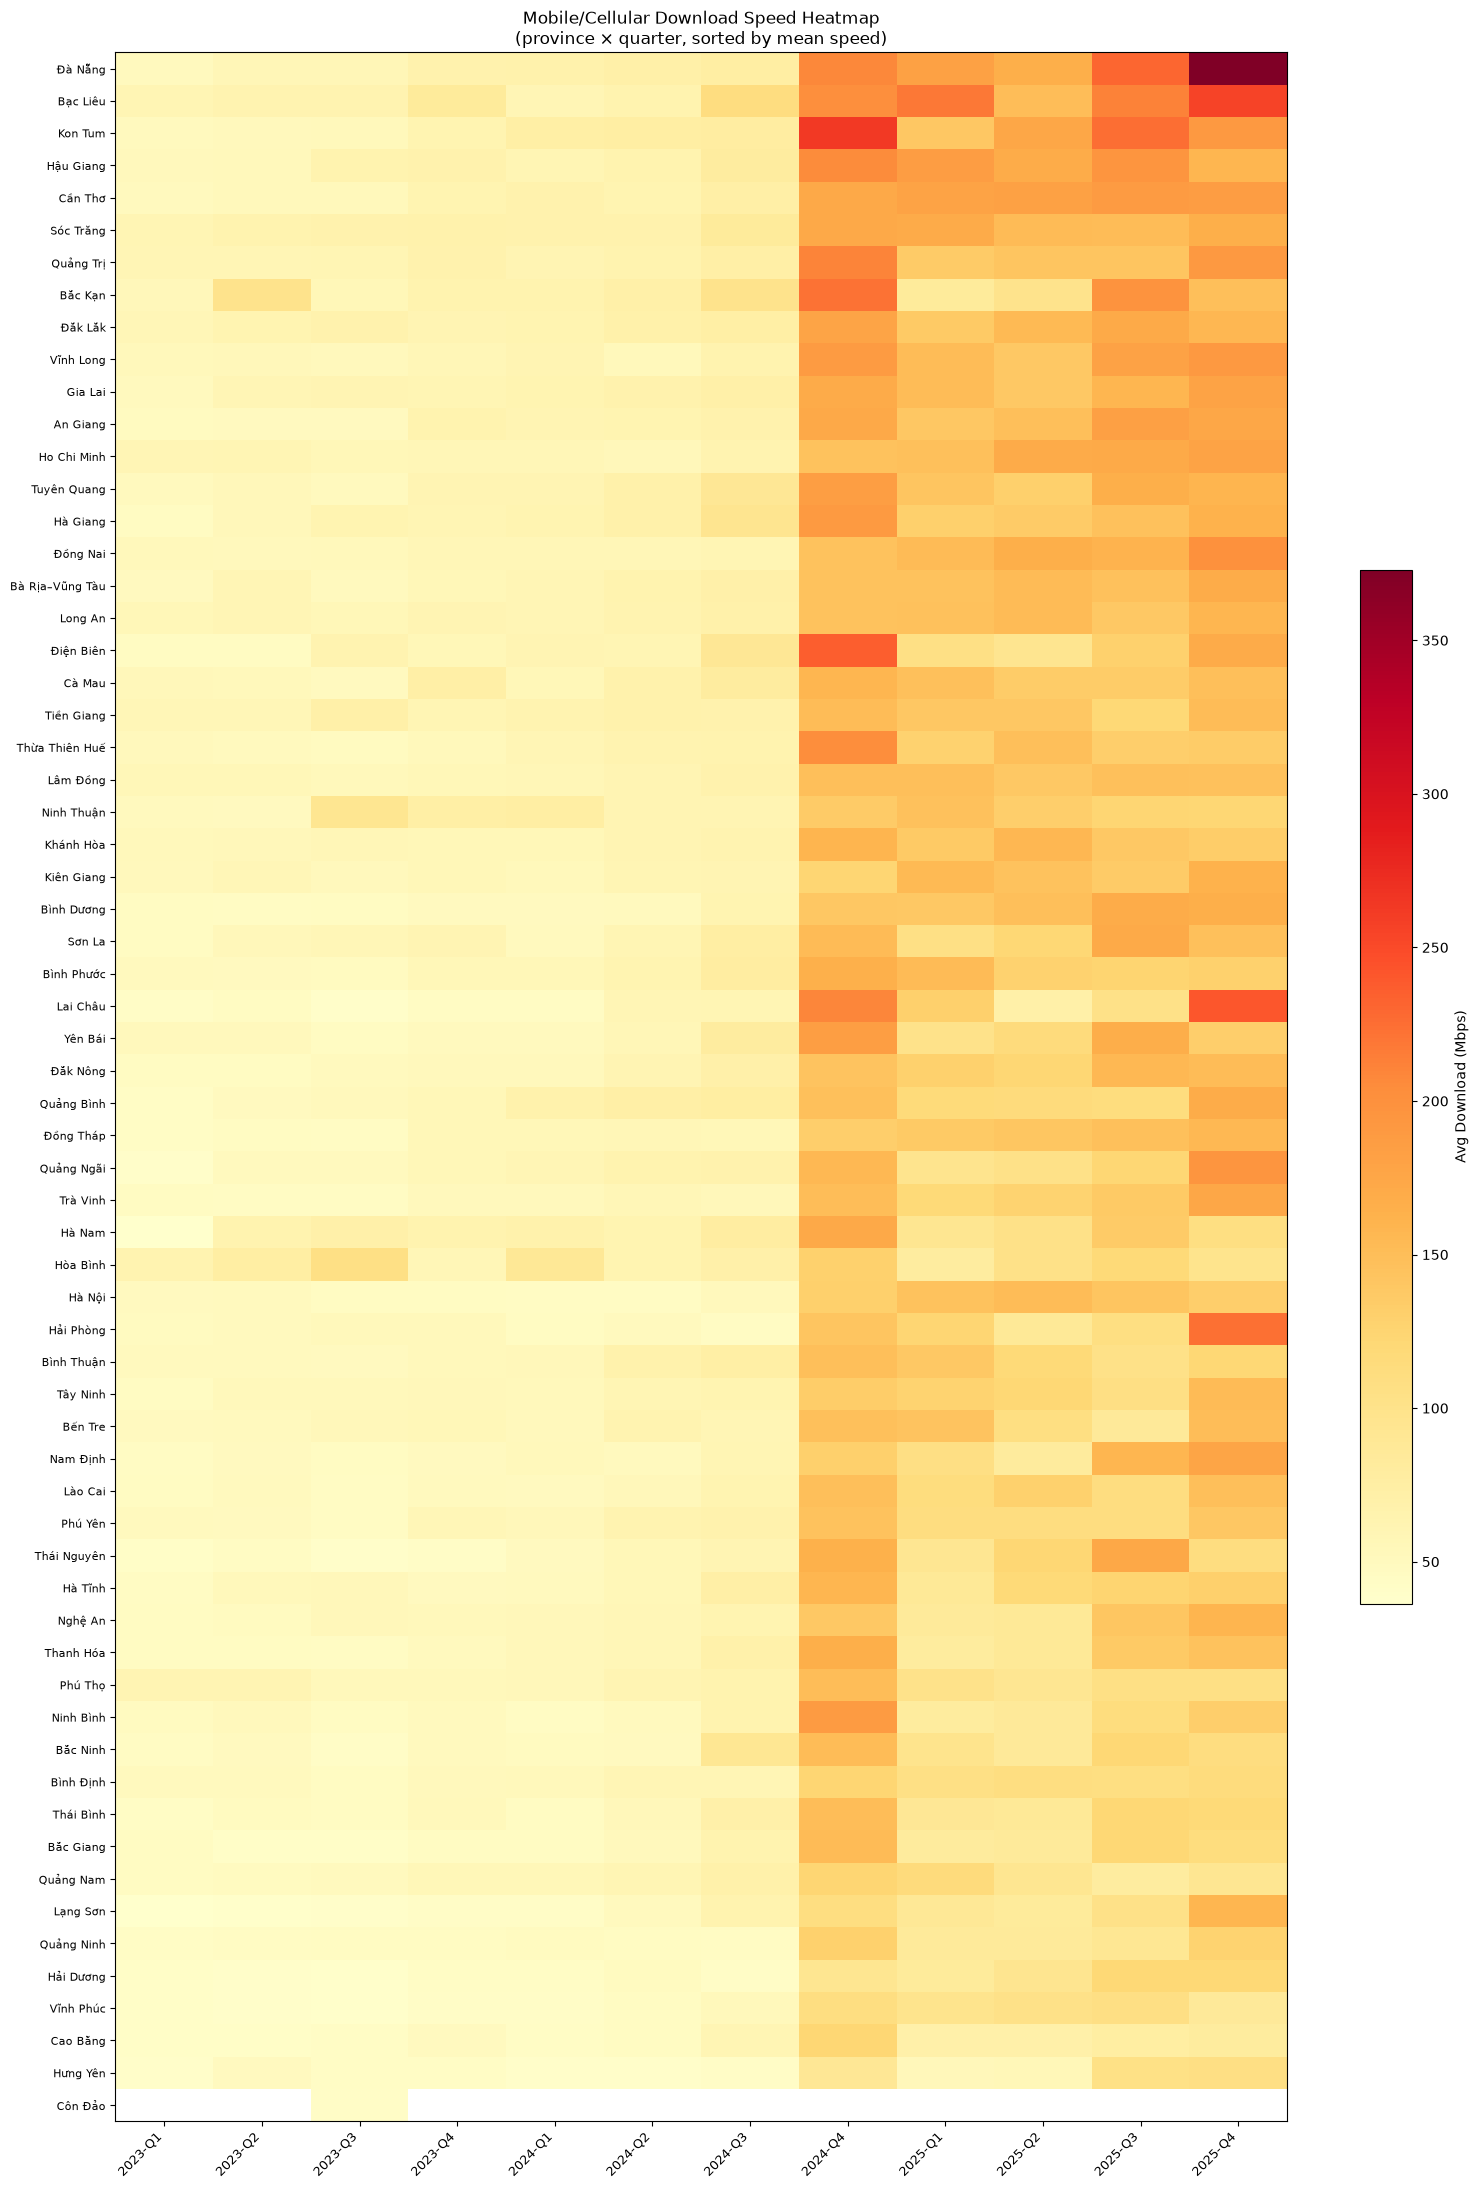

In [45]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

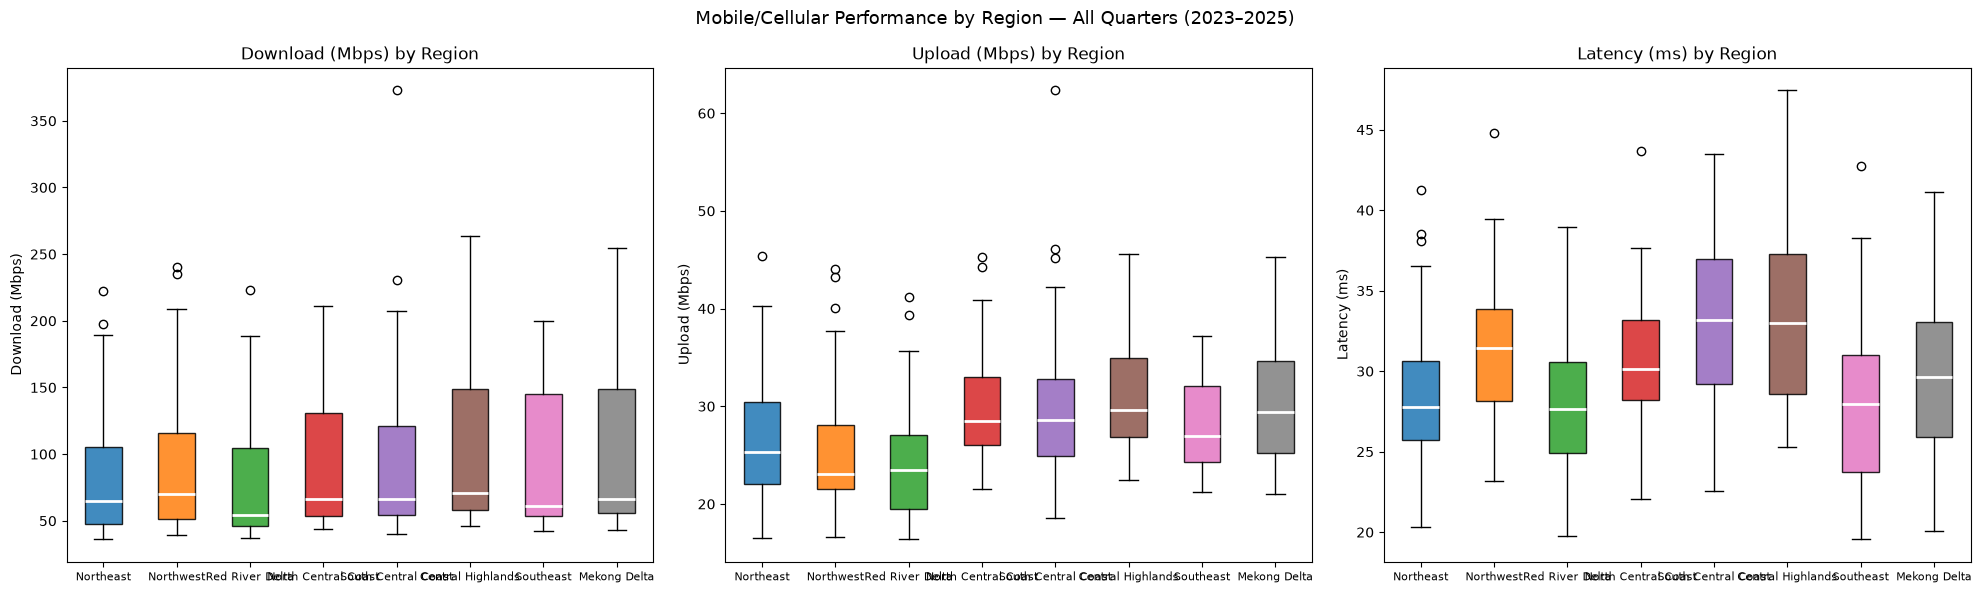

In [46]:
region_order = ['Northeast', 'Northwest', 'Red River Delta', 'North Central Coast', 'South Central Coast', 'Central Highlands', 'Southeast', 'Mekong Delta']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

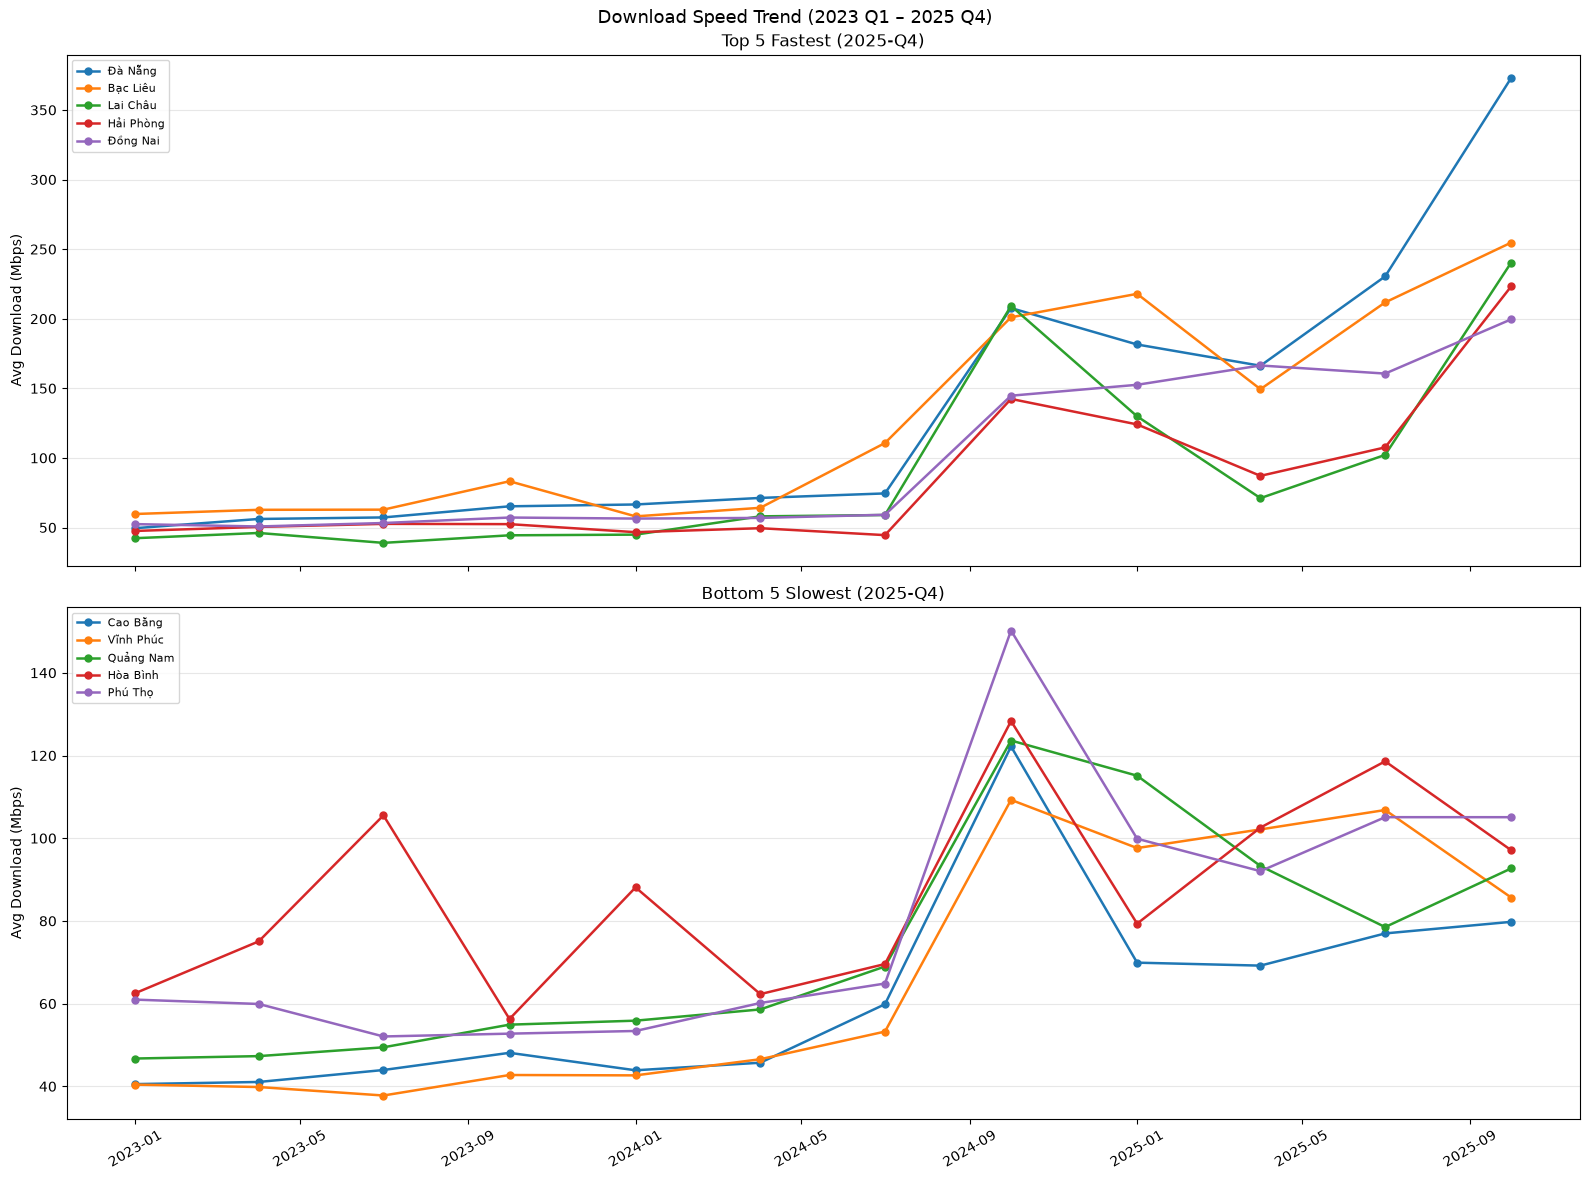

In [47]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

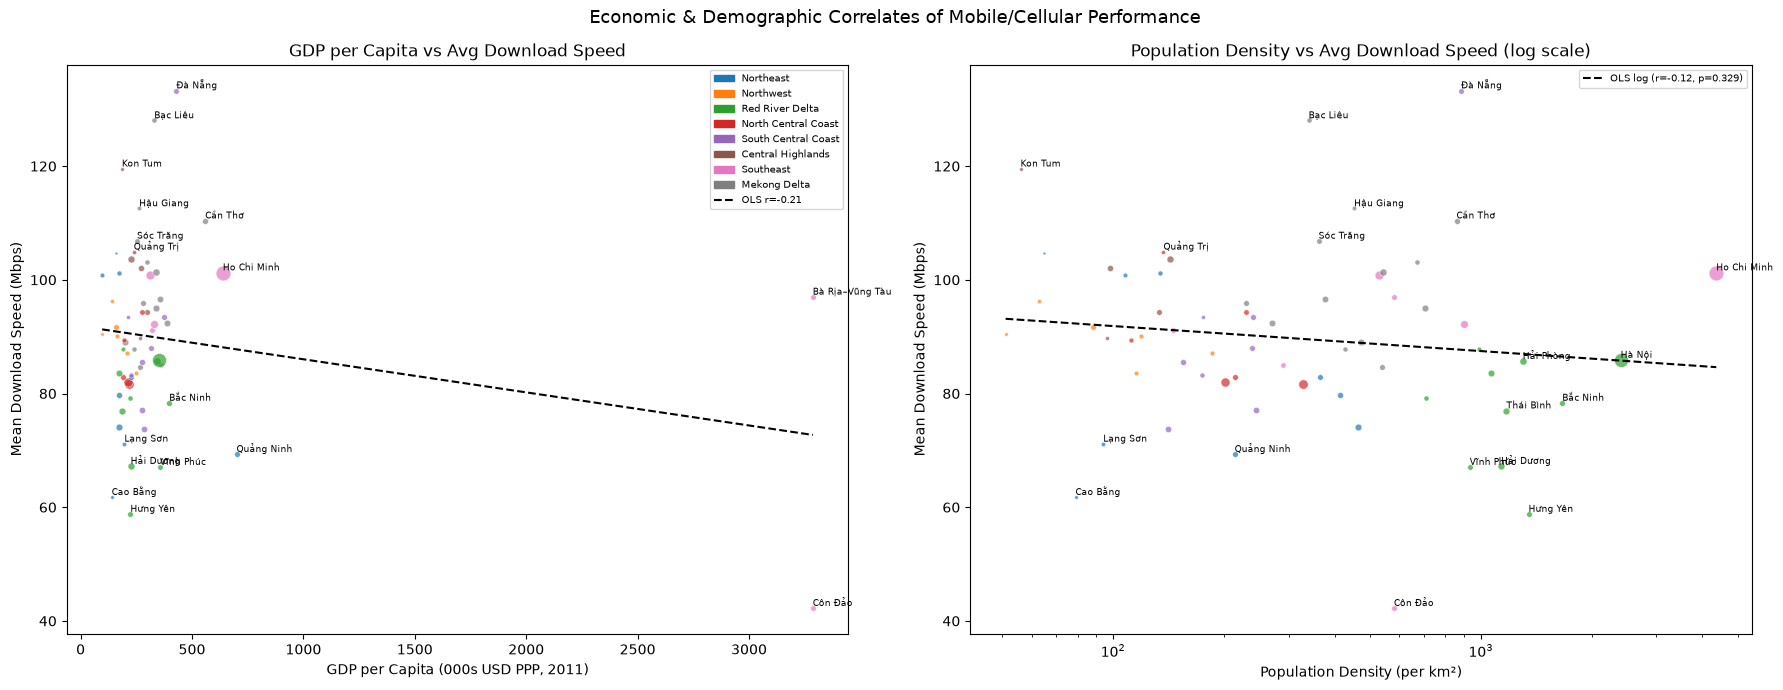

Pearson r (GDP vs download):     -0.205  p=0.1039
Pearson r (log density vs download): -0.124  p=0.3286


In [48]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD PPP, 2011)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

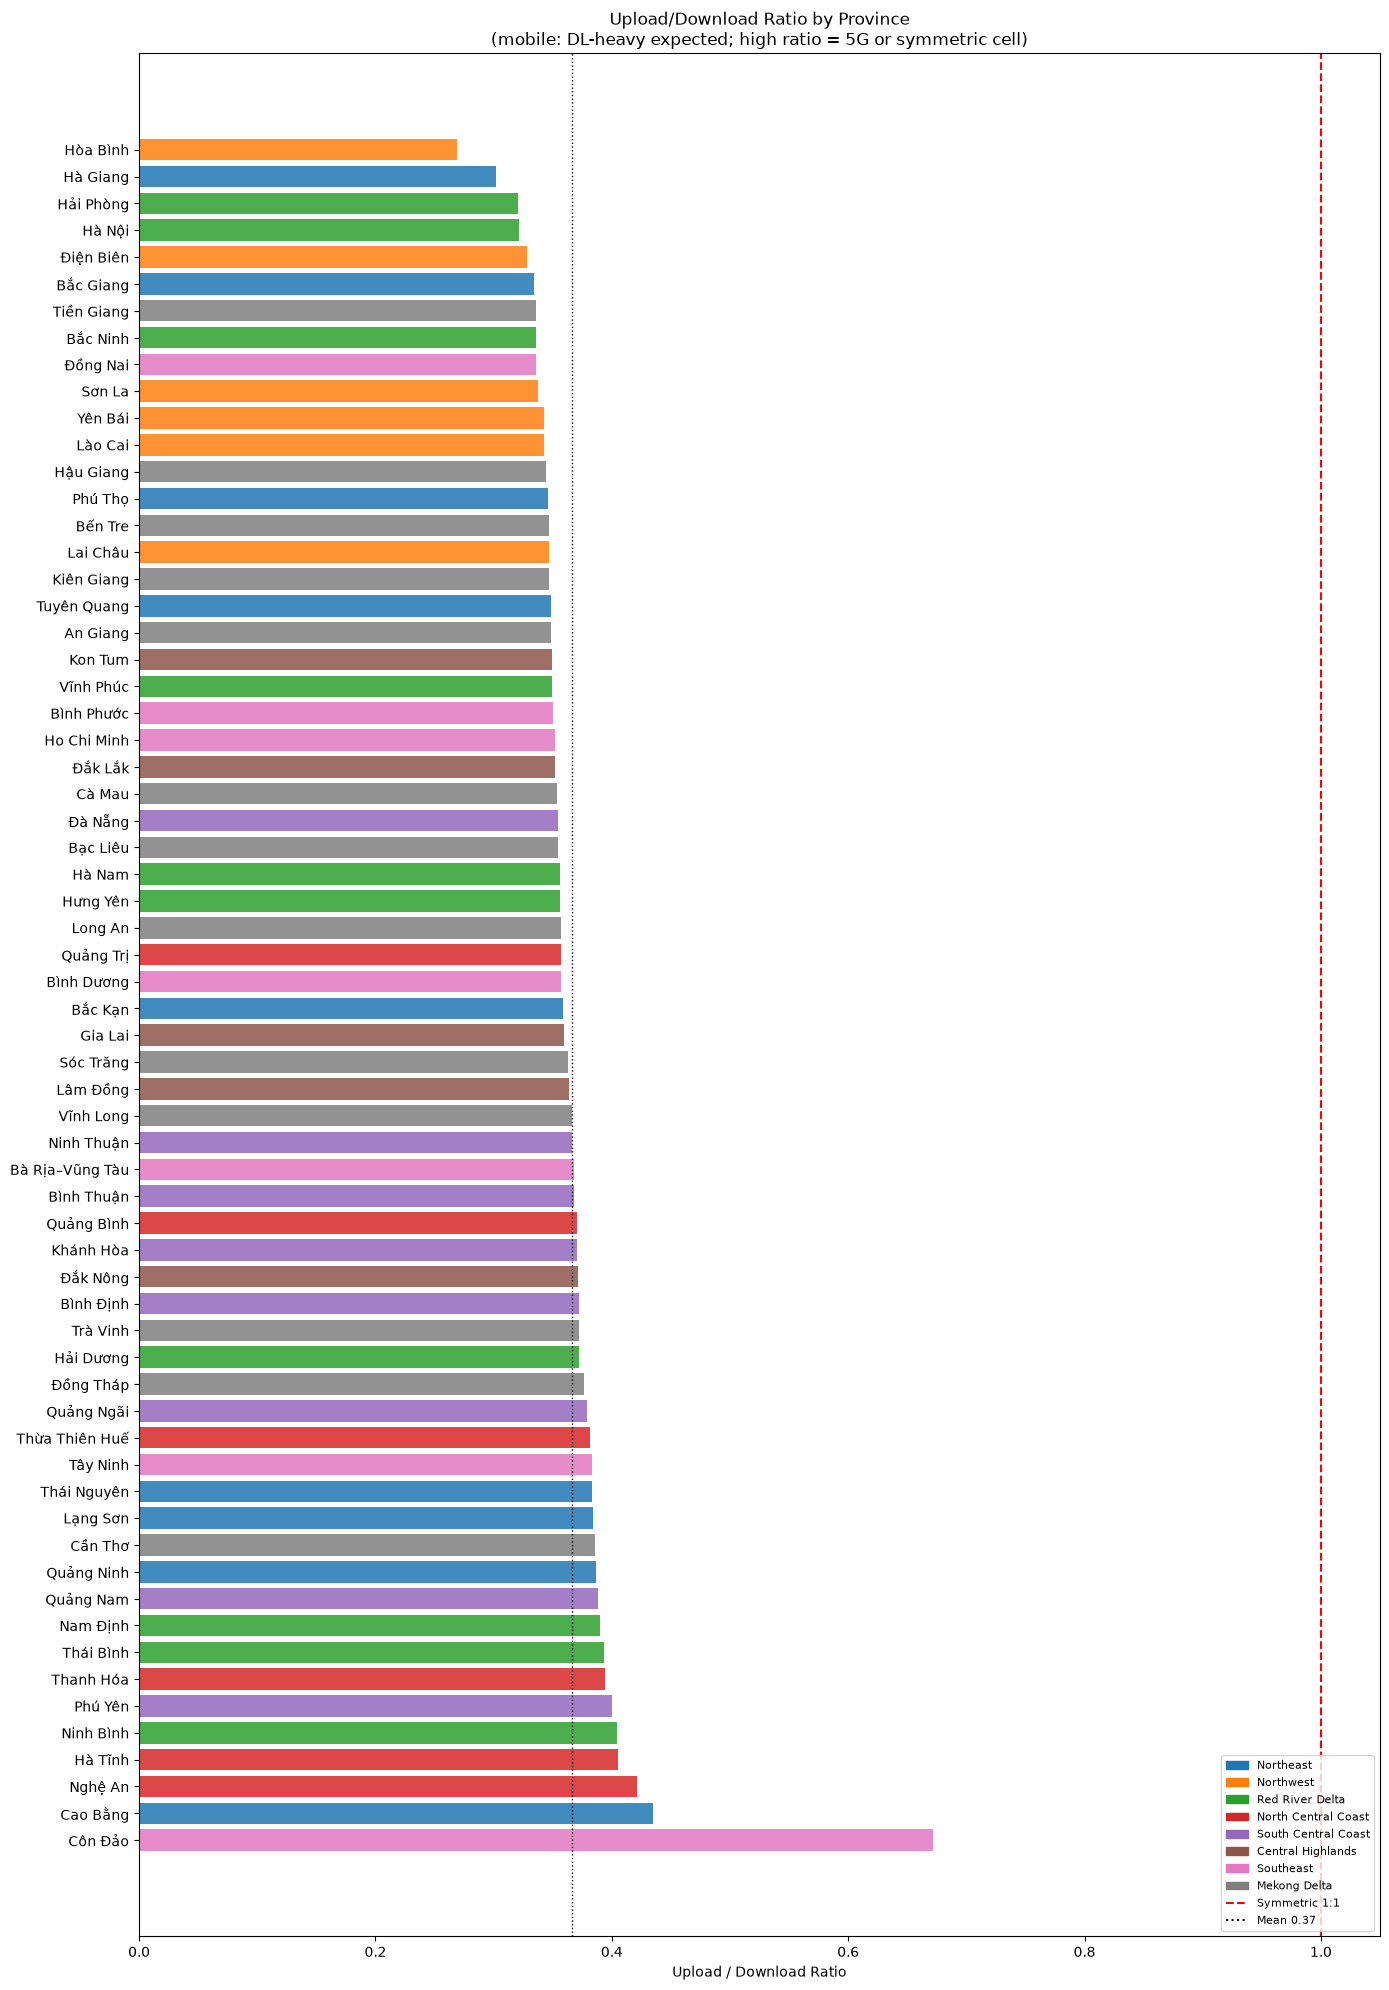

Provinces with UL/DL ratio > 0.5 (1):
   name    region  ul_dl_ratio
Côn Đảo Southeast     0.671438


In [49]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [50]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [51]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

           name              region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
        Đà Nẵng South Central Coast              1   133.29    36.34     28.01         0.35     7565.33                429834.96
       Bạc Liêu        Mekong Delta              2   128.03    36.39     27.33         0.36     1126.50                330710.59
        Kon Tum   Central Highlands              4   119.54    33.32     31.11         0.35      956.75                185404.40
      Hậu Giang        Mekong Delta              2   112.55    31.11     25.45         0.34      889.00                262983.34
        Cần Thơ        Mekong Delta              1   110.40    33.65     27.80         0.39     5021.92                559273.75
      Sóc Trăng        Mekong Delta              3   106.85    33.17     28.34         0.36     2255.50                253301.38
      Quảng Trị North Central Coast              3   104.92    32.19     28.13         0.36     1

### 13. UL/DL Symmetry — Mobile Network Quality Indicator

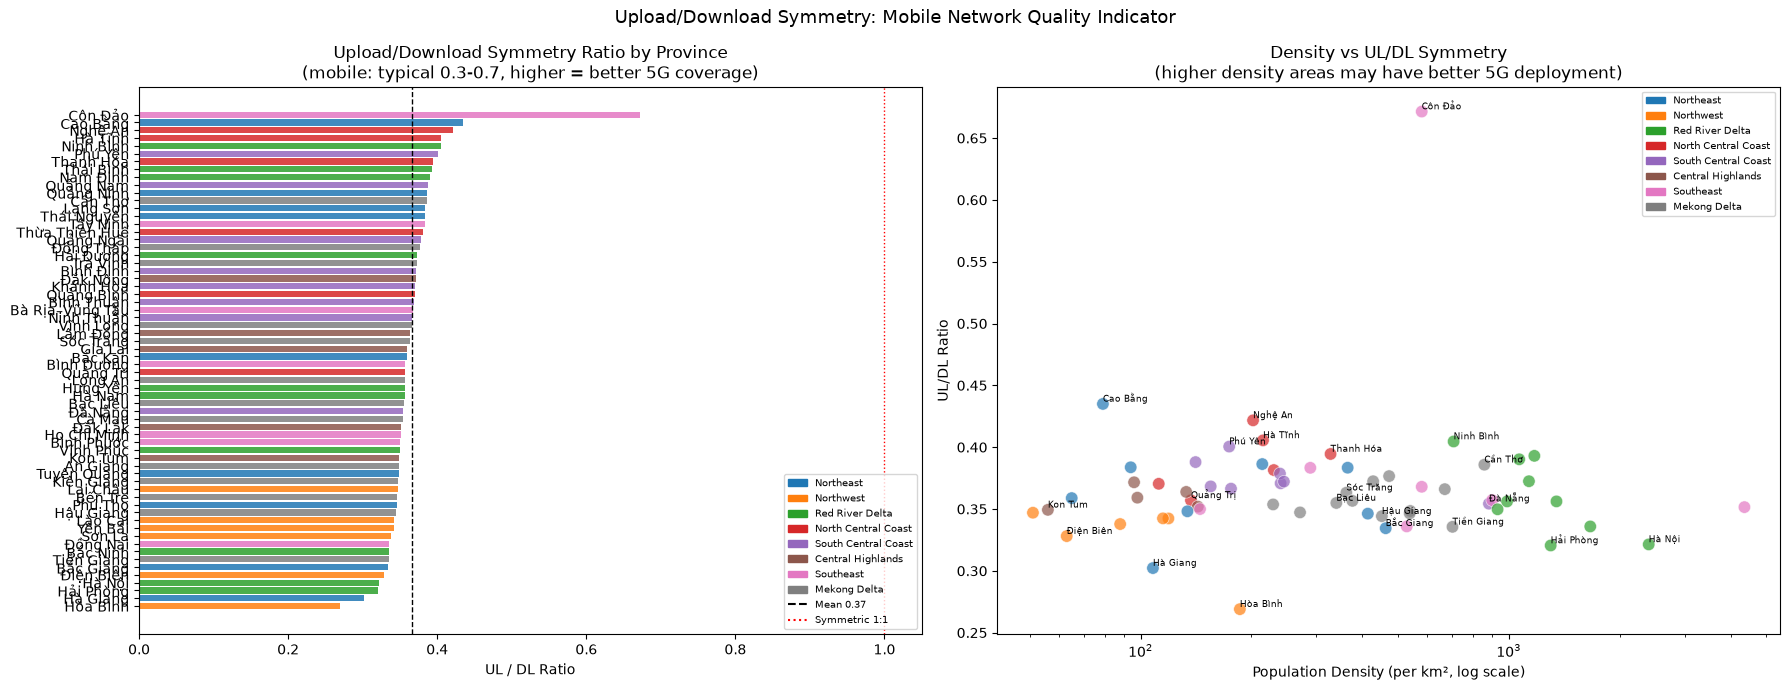

Provinces ratio > 0.5 (relatively symmetric mobile): 1 out of 64
Southeast mean ratio: 0.402
Northwest mean ratio: 0.328


In [52]:
# Mobile UL/DL ratio: typically 0.3-0.7 (DL-heavy by design)
# 5G NR can be more symmetric; high ratio may indicate 5G coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(mobile: typical 0.3-0.7, higher = better 5G coverage)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1) or row['mean_dl'] > prov_mean['mean_dl'].quantile(0.9):
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\n(higher density areas may have better 5G deployment)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Mobile Network Quality Indicator', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.5 (relatively symmetric mobile): {(prov_mean['mean_ratio'] > 0.5).sum()} out of {len(prov_mean)}")
print(f"{_top_region} mean ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].mean():.3f}")
print(f"{_bot_region} mean ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].mean():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

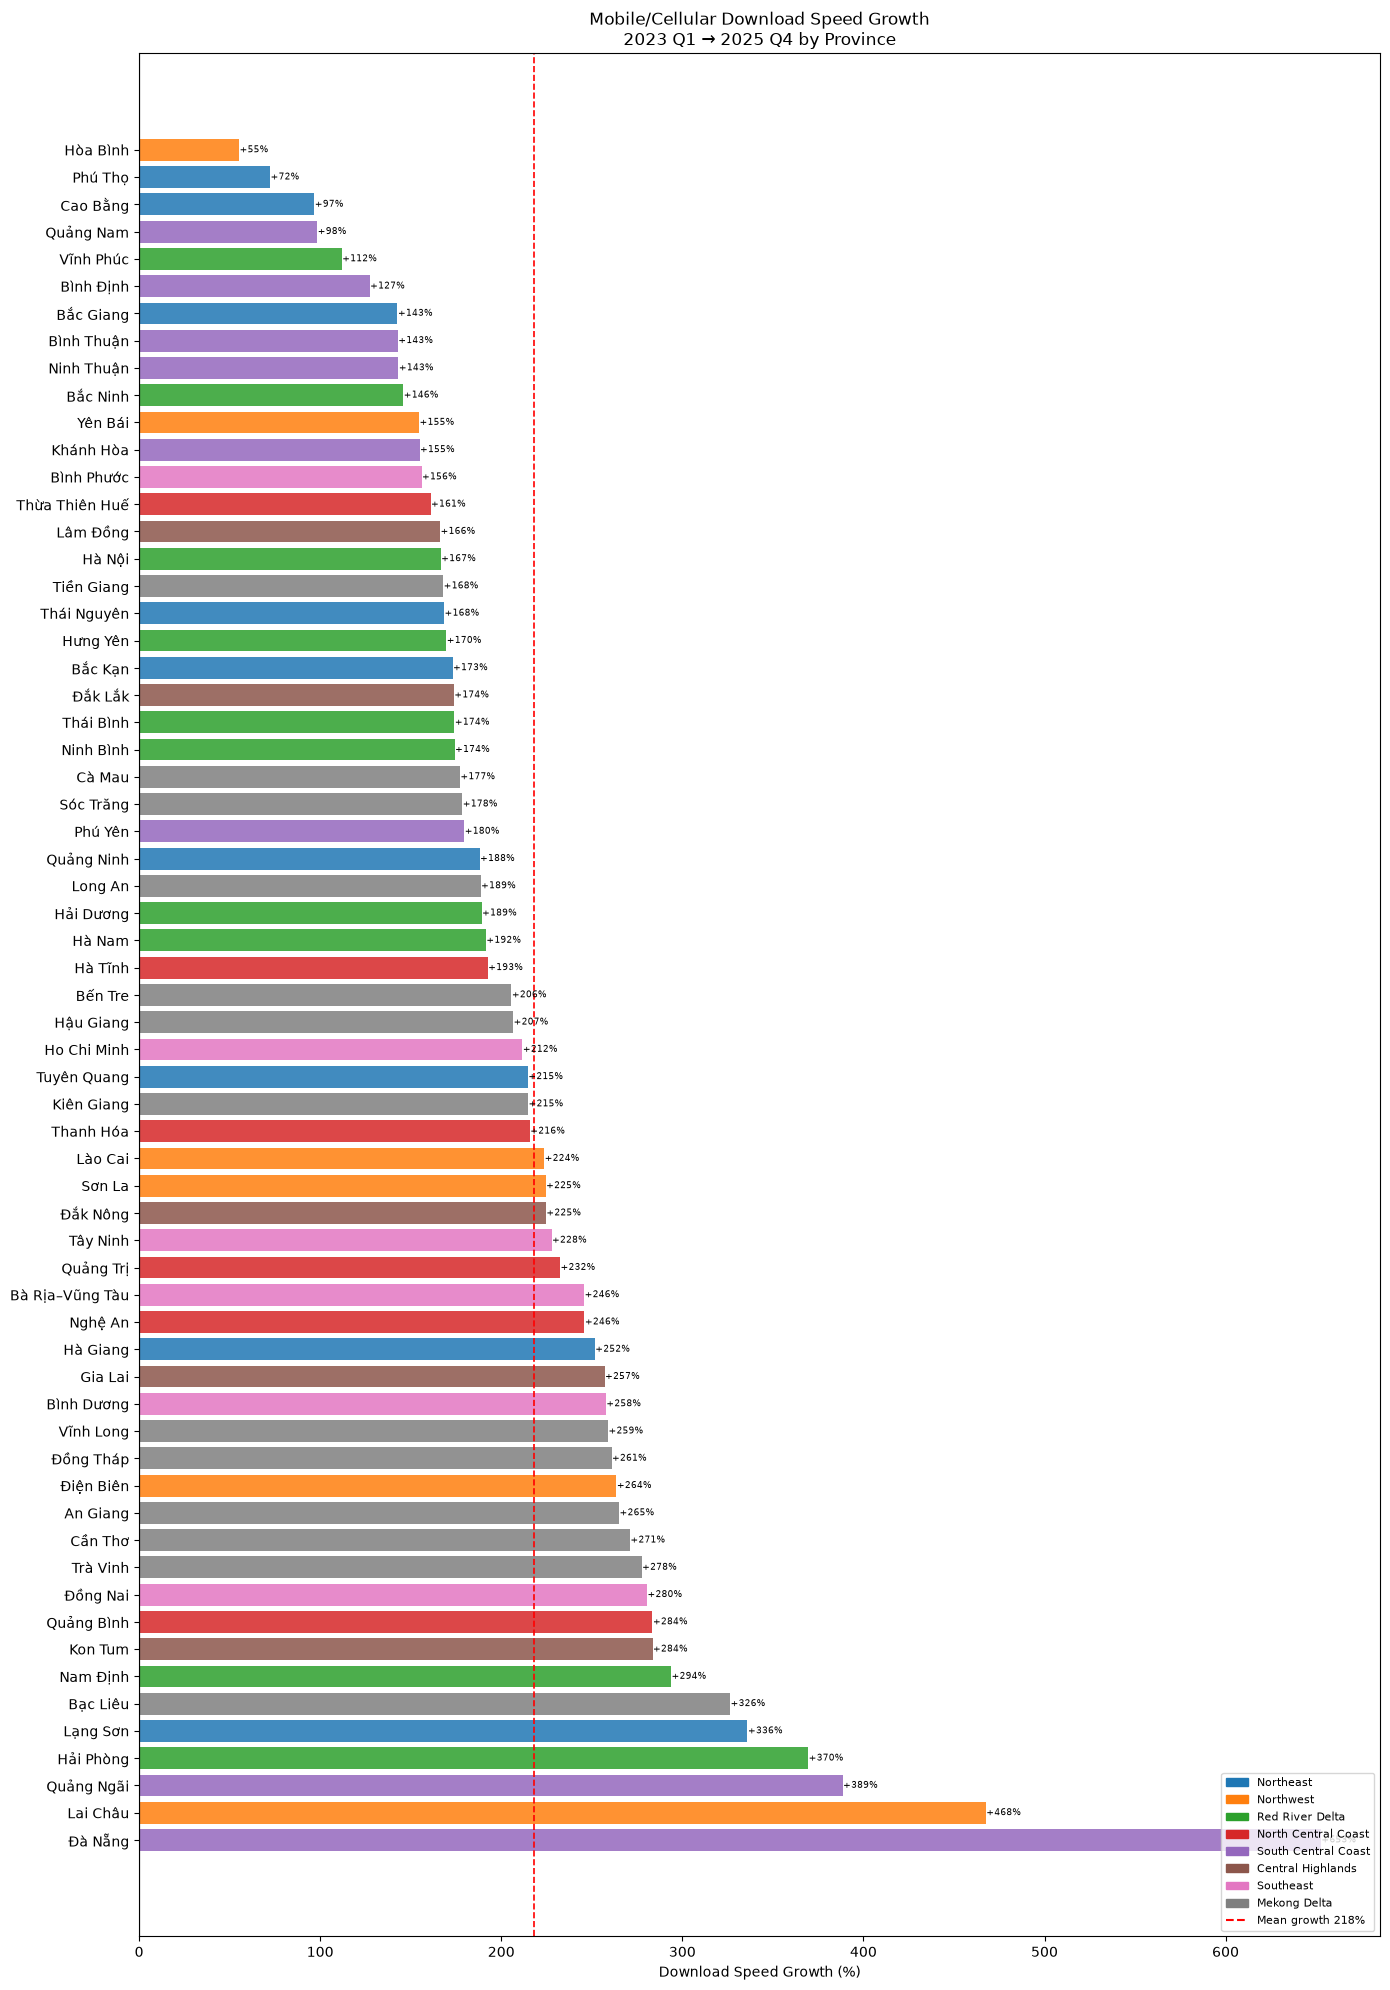

Top 10 fastest growing provinces:
      name              region  internet_tier  pct_growth
   Đà Nẵng South Central Coast              1  652.641770
  Lai Châu           Northwest              4  467.592898
Quảng Ngãi South Central Coast              2  388.507879
 Hải Phòng     Red River Delta              1  369.510503
  Lạng Sơn           Northeast              4  335.973204
  Bạc Liêu        Mekong Delta              2  326.394031
  Nam Định     Red River Delta              4  293.799065
   Kon Tum   Central Highlands              4  283.522388
Quảng Bình North Central Coast              3  283.514088
  Đồng Nai           Southeast              2  280.496116

Bottom 5 (slowest growth or decline):
     name              region  internet_tier  pct_growth
 Hòa Bình           Northwest              3   55.242628
  Phú Thọ           Northeast              4   72.353637
 Cao Bằng           Northeast              4   96.771357
Quảng Nam South Central Coast              2   98.382353
Vĩnh

In [53]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/vietnam/mobile/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [54]:
# ── Export Ookla Mobile quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_mobile_vietnam_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 757 rows → ../../data/exports/ookla_mobile_vietnam_province_quarterly.csv
          province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable        region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0         An Giang  2023-Q1  2023        1   47.876128   25.244840      30.916264       3929.0    804.0         True  Mekong Delta              1   2057000                338704.14              540
1  Bà Rịa–Vũng Tàu  2023-Q1  2023        1   48.886630   24.925304      28.251210       5374.0    716.0         True     Southeast              1   1303000               3286254.54              580
2       Bình Dương  2023-Q1  2023        1   46.291335   23.906777      28.603969      11085.0   1255.0         True     Southeast              2   2564000                327276.61              901
